In [1]:
"""VAE U-DiT mini: interactive notebook experiment.

Explores diffusion-transformer image generation using the raw architecture and
DiffusionModel wrapper selected in its cells. Related numbered copies retain their own
architecture, conditioning, reshaping, and training choices; this file uses the literal
values written below.

Inputs are loaded image/label arrays and the model, schedule, optimizer, callback, and
fit settings in the setup cells. get_dataset documents byte scaling, optional channel
insertion, label handling, shuffle behavior, and batch defaults. Wrapper
constructor/method docstrings define the remaining selected modes.

Outputs include a trained model, fit histories, sampled images, and any configured
callback/checkpoint files. Executing cells may download data, allocate TensorFlow
resources, train weights, and write artifacts. Cell definitions do not run a complete
experiment automatically, and notebook-wide names depend on prior setup execution.
"""

import init

In [2]:
epochs = 50 # or 50 to get acc of 0.9850

In [3]:
import tensorflow as tf


def get_dataset(x, y, batch_size=128, shuffle_buffer=10_000, drop_remainder=True):
    """Scale image bytes to diffusion space and batch aligned labels.

    The affine transform does not clip values. No prefetching, repetition, validation
    split, or deterministic shuffle seed is added. Labels remain aligned with images
    while shuffling.

    Args:
        x (np.ndarray): Image values nominally in [0, 255]. Trailing image dimensions
            are preserved; supply the channel dimension required by the model.
        y (np.ndarray): Labels with the same leading length as x. Values and label shape
            are preserved.
        batch_size (int): Number of examples in each dataset batch. Defaults to ``128``.
        shuffle_buffer (int | None): None preserves input order; a positive integer
            enables shuffling without an explicit operation seed. TensorFlow global
            seeding can still control this randomness. Defaults to ``10000``.
        drop_remainder (bool): True discards an incomplete final batch; False retains
            it. Defaults to ``True``.

    Returns:
        tf.data.Dataset: Finite (images, labels) batches, with float32 image values
        transformed as 2*x/255-1 and the configured remainder policy.
    """

    x = x.astype("float32") / 255.0
    x = (x * 2.0) - 1.0
    # x = x[..., None]

    dataset = tf.data.Dataset.from_tensor_slices((x, y))

    # A supplied buffer enables random shuffling; None keeps input order.
    if shuffle_buffer is not None:
        dataset = dataset.shuffle(shuffle_buffer)

    dataset = dataset.batch(batch_size, drop_remainder=drop_remainder)

    return dataset

In [4]:
from tensorflow.keras import datasets, layers

import numpy as np


(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

x_train = np.expand_dims(x_train, -1)
x_train = layers.ZeroPadding2D((2, 2))(x_train).numpy()

x_test = np.expand_dims(x_test, -1)
x_test = layers.ZeroPadding2D((2, 2))(x_test).numpy()

trainset = get_dataset(x_train, y_train)
valset = get_dataset(x_test, y_test, shuffle_buffer=None, drop_remainder=False)

In [5]:
from diffusion.models.wrapper.diffusion_model import DiffusionModel
from diffusion.models.transformer.diffusion_transformer import DiffusionTransformer


vit = DiffusionTransformer(
    image_size=32, 
    use_cfg=False, 
    dim=16, 
    dim_forced=False, 
    depth=15, 
    connection_ids_dict={8: (3,), 10: (1,), 12: (7,)}, 
    cross_attention_ids_dict={13: (9,), 15: (11,)}, 
    cross_attention_kwargs={
        "use_layer_norm": True, 
        "ln_no_adaptation": False
    }, 
    vit_block_ids=[1, 3, 5, 13, 15], 
    use_decoder_ids=[13, 15], 
    vit_block_mlp_output_dims={1: 16, 3: 32, 5: 32, 13: 16, 15: 16}, 
    downsample_ids=[2, 4], 
    downsample_kwargs={
        "pos_embed_type": "2d_sincos", 
    }, 
    upsample_ids=[12, 14], 
    upsample_kwargs={
        "pos_embed_type": "2d_sincos", 
        "scaling_method": "interpolate", 
        "scaling_interpolation_method": "bilinear"
    }, 
    reshaper_ids_dict={
        6: "flatten", 7: "unflatten", 
        8: "flatten", 9: "unflatten", 
        10: "flatten", 11: "unflatten"
    }, 
    reshaper_kwargs={
        "add_kl": True, 
        "latent_dim_ratio": [1 / 64, 1 / 256, 1 / 512]
    }
)
model = DiffusionModel(
    network=vit, 
    swap_noise_image=True, 
    kl_loss_coef=0.01, 
    modify_first_t=True, 
    train_noisified_max_timesteps=0, 
    test_noisified_max_timesteps=0, 
) # 

vit.summary()

Model: "diffusion_transformer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 depth_0_patch_embedder (Pat  (None, 256, 16)          80        
 chEmbedding)                                                    
                                                                 
 depth_0_time_embedder (Cond  (None, 16)               16000     
 itionEmbedding)                                                 
                                                                 
 depth_0_label_embedder (Con  (None, 16)               160       
 ditionEmbedding)                                                
                                                                 
 depth_0_time_label_merger (  (None, 16)               0         
 Add)                                                            
                                                                 
 depth_1_encoder_block (Visi  (None, 256, 16)

In [6]:
from tensorflow.keras import optimizers


lr_schedule = optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3, 
    decay_steps=epochs * len(trainset), #  * 11
)

model.compile(
    optimizer=optimizers.Adam(lr_schedule), 
    loss="mse", 
    # run_eagerly=True
)

In [7]:
from tensorflow.keras import callbacks

from diffusion import ImageGeneratorCallback
from common.lr_logger_callback import LrLoggerCallback


callbacks_list = [
    LrLoggerCallback(), 
    callbacks.ProgbarLogger(count_mode="steps"), 
    ImageGeneratorCallback(), 
]

In [8]:
# model.set_current_resolution(14)

In [9]:
# model.set_current_resolution(28)

In [10]:
# model.set_current_resolution(56)

In [11]:
# model.set_current_resolution(16)

Epoch 1/50
468/468 [==============================] - 58s 94ms/step - loss: 0.2422 - noise_loss: 0.2326 - kl_loss: 0.9646 - val_loss: 0.7710 - val_noise_loss: 0.6441 - val_image_loss: 0.0000e+00 - val_kl_loss: 12.6895 - learning_rate: 9.9901e-04


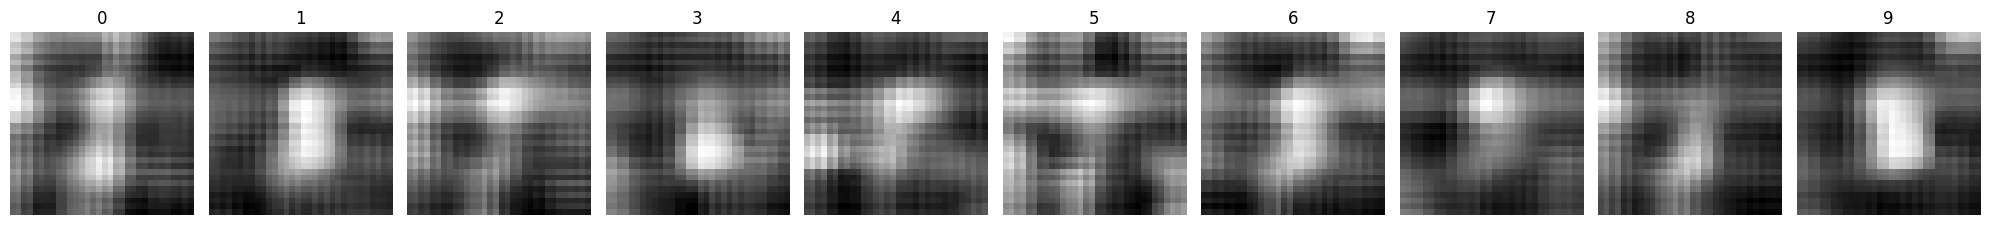

Epoch 2/50
468/468 [==============================] - 43s 91ms/step - loss: 0.1627 - noise_loss: 0.1500 - kl_loss: 1.2684 - val_loss: 0.4260 - val_noise_loss: 0.3825 - val_image_loss: 0.0000e+00 - val_kl_loss: 4.3479 - learning_rate: 9.9606e-04


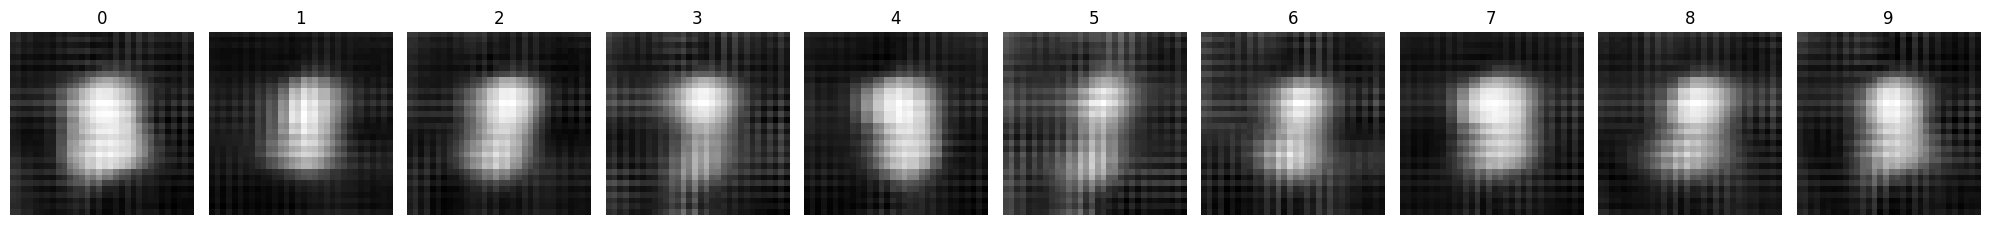

Epoch 3/50
468/468 [==============================] - 43s 91ms/step - loss: 0.1505 - noise_loss: 0.1336 - kl_loss: 1.6881 - val_loss: 0.2835 - val_noise_loss: 0.2648 - val_image_loss: 0.0000e+00 - val_kl_loss: 1.8673 - learning_rate: 9.9114e-04


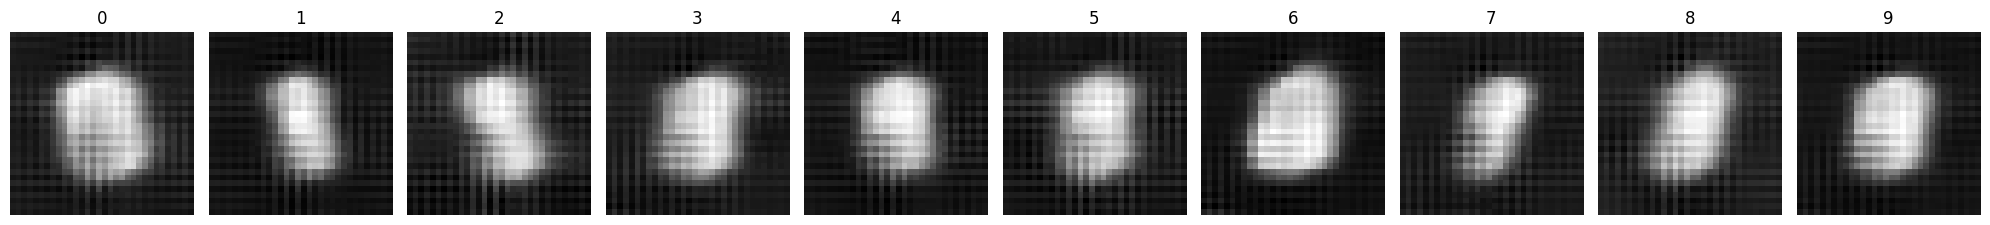

Epoch 4/50
468/468 [==============================] - 43s 91ms/step - loss: 0.1453 - noise_loss: 0.1254 - kl_loss: 1.9939 - val_loss: 0.2232 - val_noise_loss: 0.2098 - val_image_loss: 0.0000e+00 - val_kl_loss: 1.3334 - learning_rate: 9.8429e-04


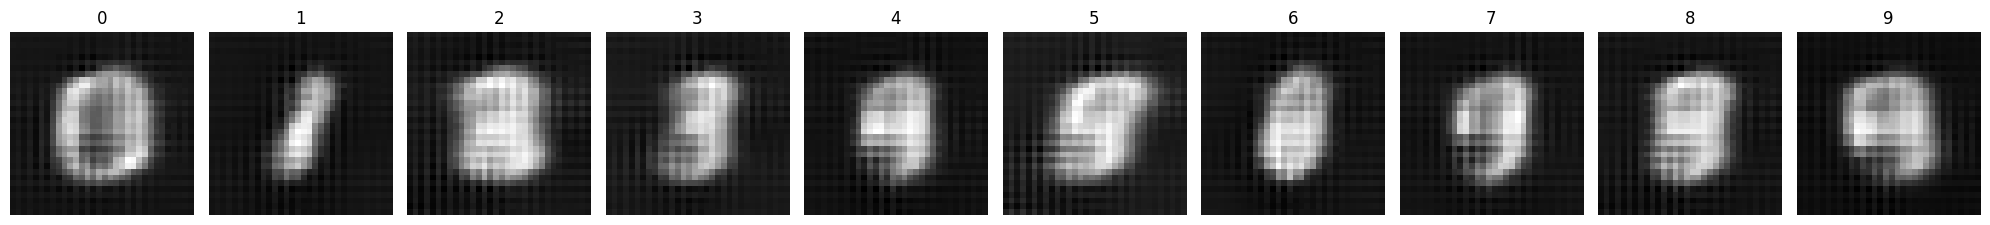

Epoch 5/50
468/468 [==============================] - 43s 91ms/step - loss: 0.1422 - noise_loss: 0.1201 - kl_loss: 2.2059 - val_loss: 0.1876 - val_noise_loss: 0.1735 - val_image_loss: 0.0000e+00 - val_kl_loss: 1.4145 - learning_rate: 9.7553e-04


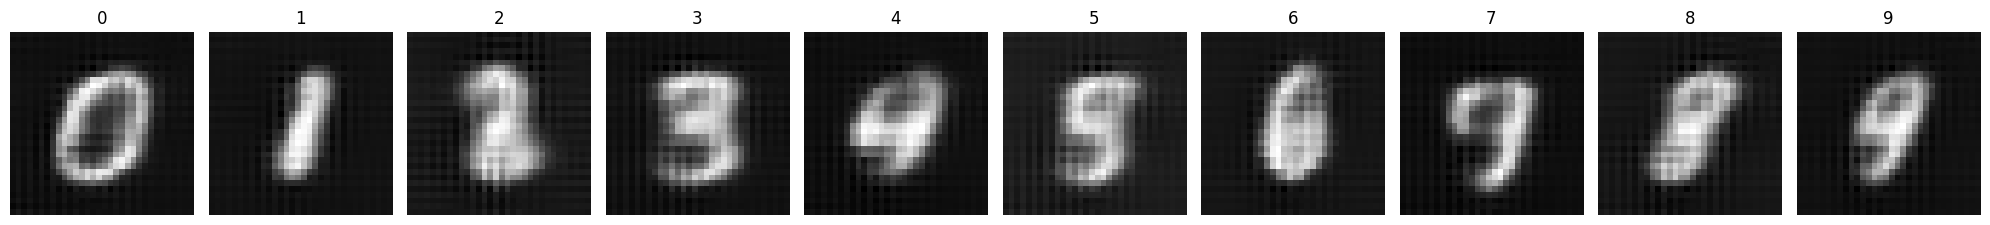

Epoch 6/50
468/468 [==============================] - 43s 91ms/step - loss: 0.1403 - noise_loss: 0.1168 - kl_loss: 2.3490 - val_loss: 0.1639 - val_noise_loss: 0.1471 - val_image_loss: 0.0000e+00 - val_kl_loss: 1.6758 - learning_rate: 9.6489e-04


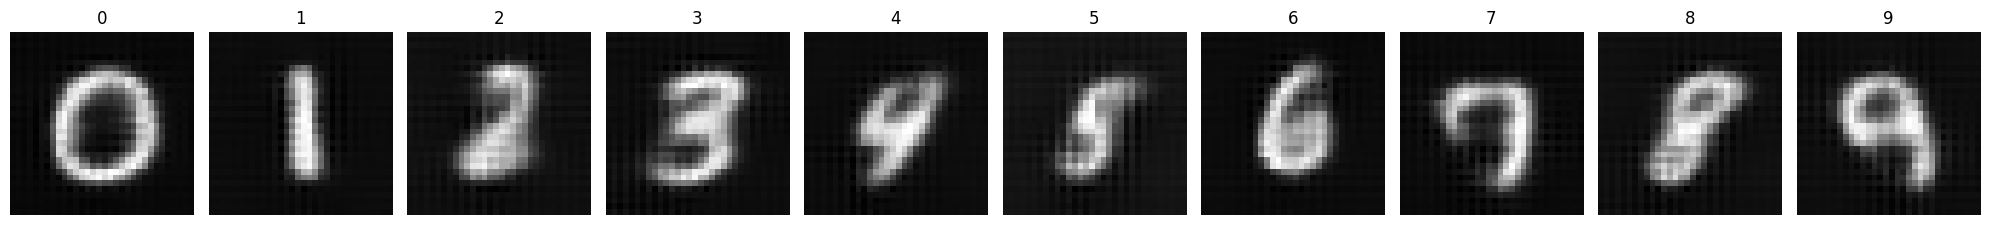

Epoch 7/50
468/468 [==============================] - 43s 92ms/step - loss: 0.1391 - noise_loss: 0.1145 - kl_loss: 2.4586 - val_loss: 0.1502 - val_noise_loss: 0.1309 - val_image_loss: 0.0000e+00 - val_kl_loss: 1.9331 - learning_rate: 9.5241e-04


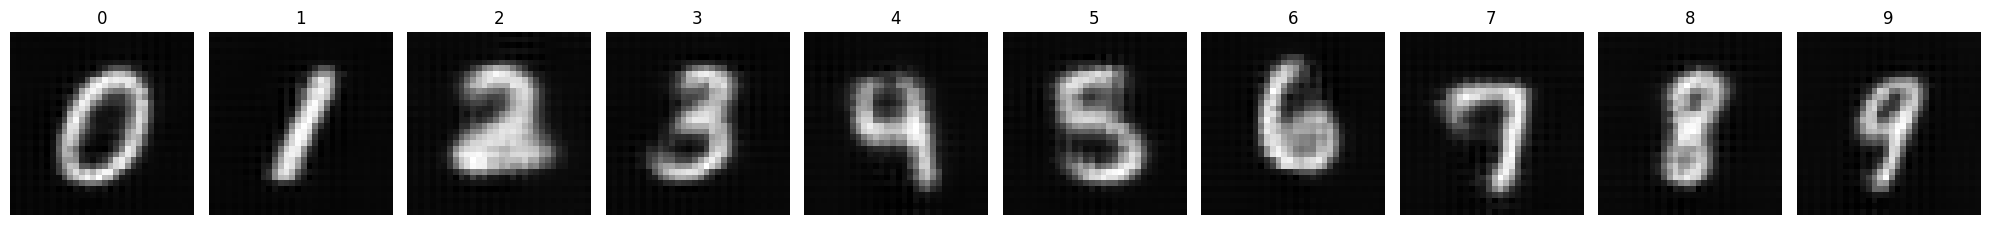

Epoch 8/50
468/468 [==============================] - 43s 91ms/step - loss: 0.1376 - noise_loss: 0.1122 - kl_loss: 2.5352 - val_loss: 0.1423 - val_noise_loss: 0.1209 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.1363 - learning_rate: 9.3815e-04


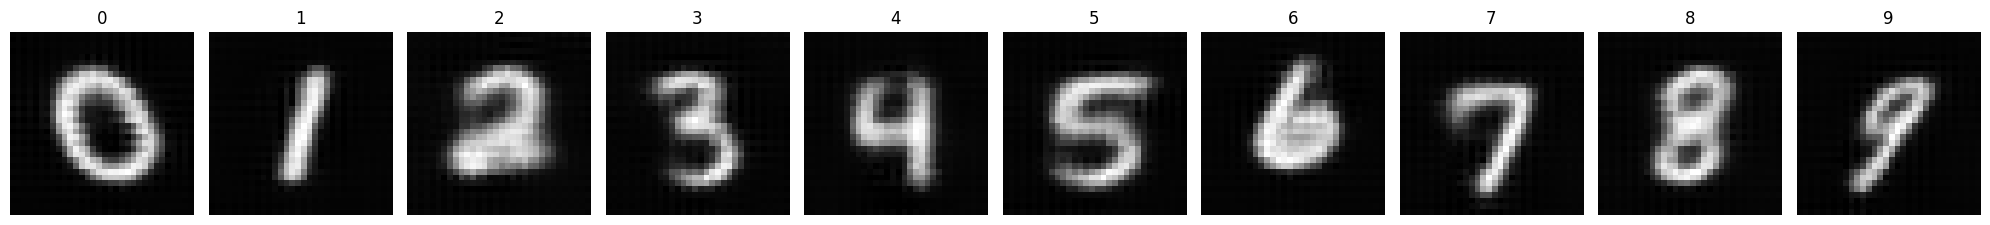

Epoch 9/50
468/468 [==============================] - 43s 92ms/step - loss: 0.1370 - noise_loss: 0.1108 - kl_loss: 2.6195 - val_loss: 0.1385 - val_noise_loss: 0.1154 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.3021 - learning_rate: 9.2216e-04


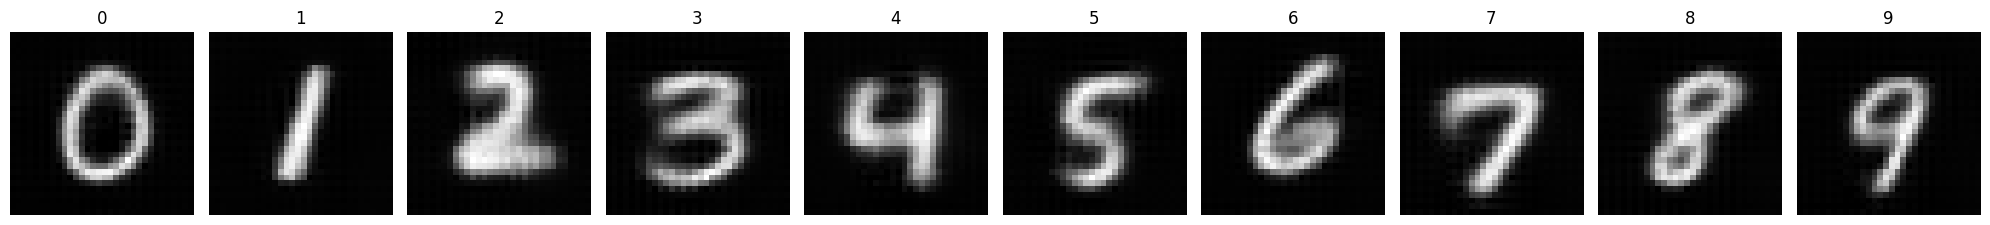

Epoch 10/50
468/468 [==============================] - 43s 92ms/step - loss: 0.1361 - noise_loss: 0.1093 - kl_loss: 2.6771 - val_loss: 0.1361 - val_noise_loss: 0.1118 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.4293 - learning_rate: 9.0451e-04


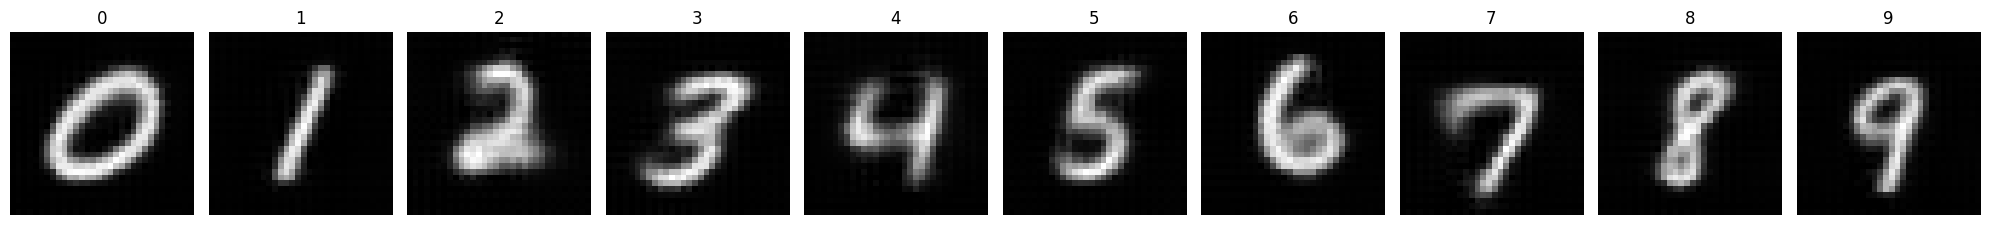

Epoch 11/50
468/468 [==============================] - 43s 92ms/step - loss: 0.1355 - noise_loss: 0.1081 - kl_loss: 2.7352 - val_loss: 0.1343 - val_noise_loss: 0.1090 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.5299 - learning_rate: 8.8526e-04


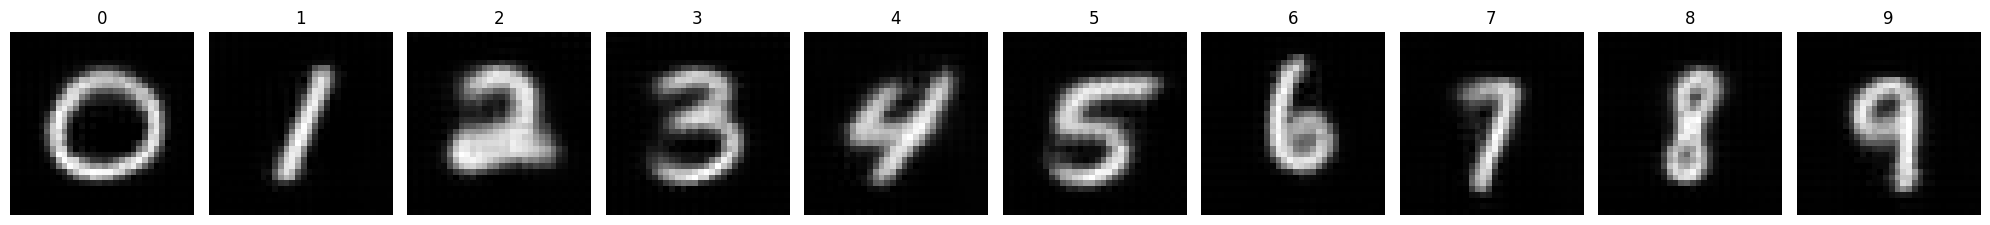

Epoch 12/50
468/468 [==============================] - 43s 92ms/step - loss: 0.1346 - noise_loss: 0.1068 - kl_loss: 2.7843 - val_loss: 0.1335 - val_noise_loss: 0.1074 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.6097 - learning_rate: 8.6448e-04


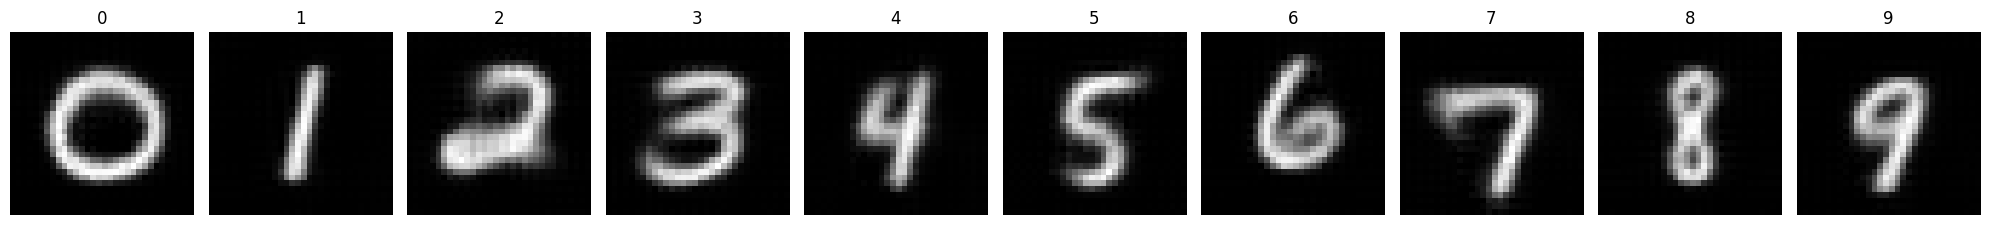

Epoch 13/50
468/468 [==============================] - 43s 92ms/step - loss: 0.1343 - noise_loss: 0.1058 - kl_loss: 2.8437 - val_loss: 0.1329 - val_noise_loss: 0.1061 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.6782 - learning_rate: 8.4227e-04


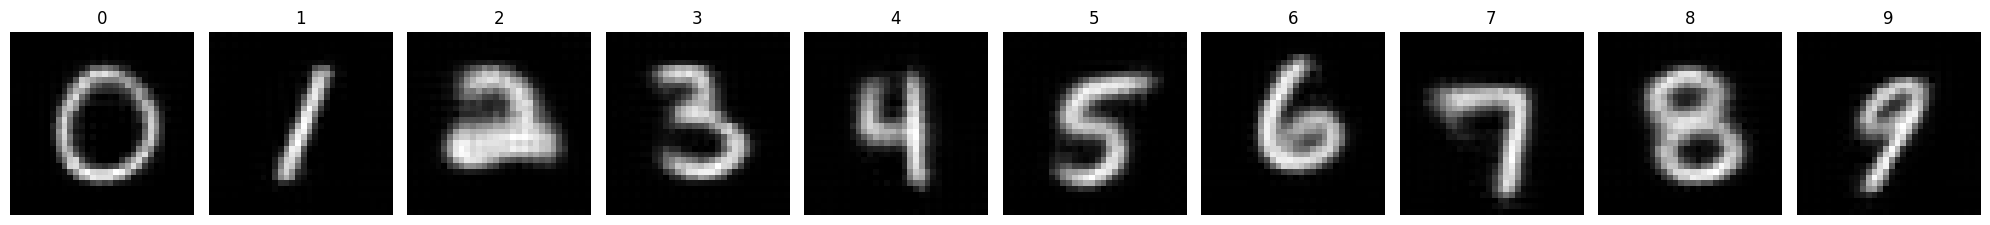

Epoch 14/50
468/468 [==============================] - 43s 92ms/step - loss: 0.1338 - noise_loss: 0.1048 - kl_loss: 2.9062 - val_loss: 0.1320 - val_noise_loss: 0.1046 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.7445 - learning_rate: 8.1871e-04


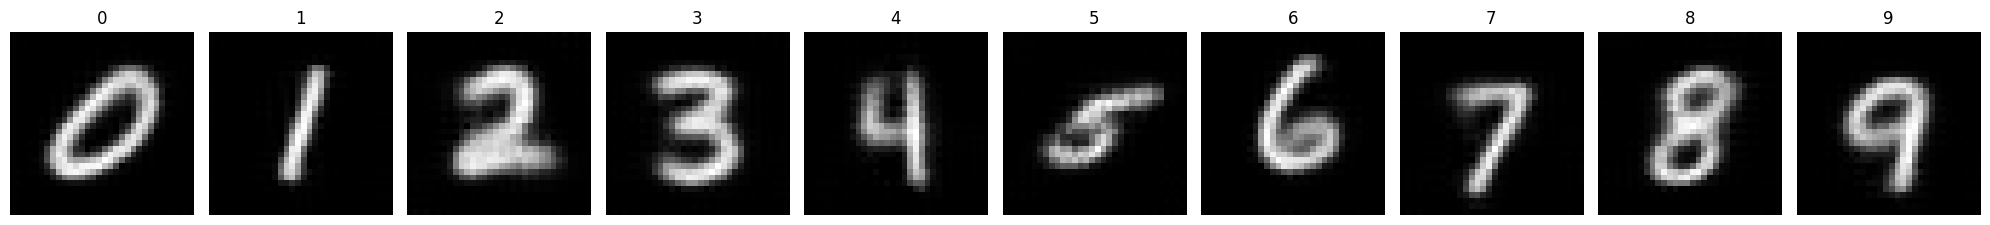

Epoch 15/50
468/468 [==============================] - 42s 91ms/step - loss: 0.1333 - noise_loss: 0.1039 - kl_loss: 2.9453 - val_loss: 0.1314 - val_noise_loss: 0.1034 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.8046 - learning_rate: 7.9389e-04


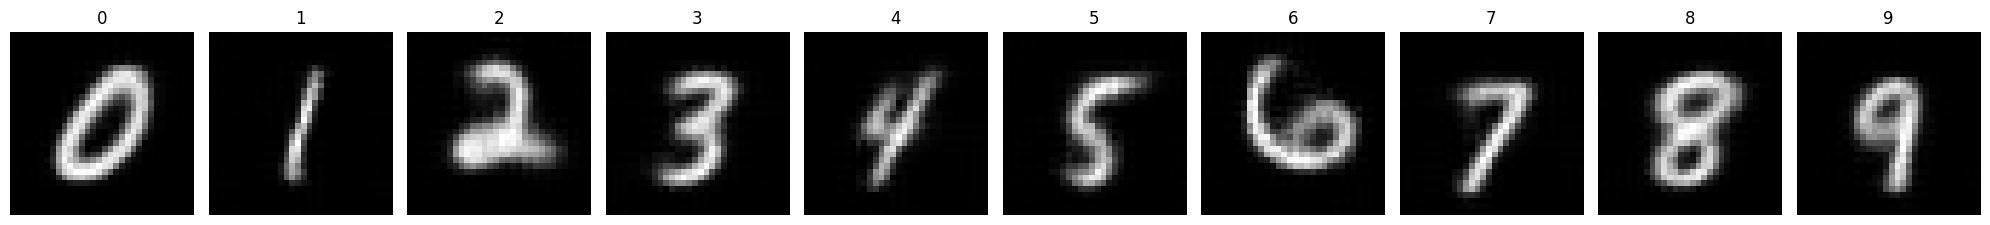

Epoch 16/50
468/468 [==============================] - 43s 92ms/step - loss: 0.1330 - noise_loss: 0.1032 - kl_loss: 2.9746 - val_loss: 0.1311 - val_noise_loss: 0.1026 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.8518 - learning_rate: 7.6791e-04


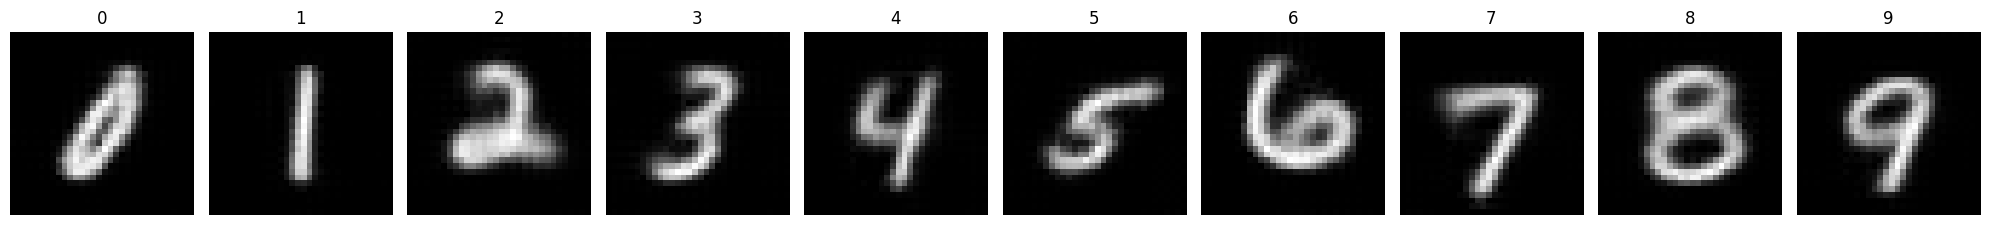

Epoch 17/50
468/468 [==============================] - 43s 93ms/step - loss: 0.1326 - noise_loss: 0.1025 - kl_loss: 3.0075 - val_loss: 0.1306 - val_noise_loss: 0.1016 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.8962 - learning_rate: 7.4088e-04


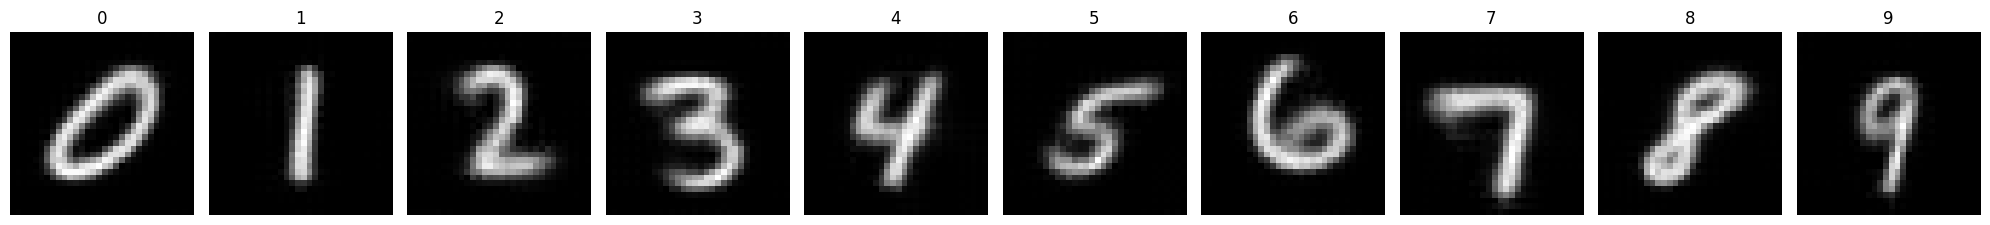

Epoch 18/50
468/468 [==============================] - 43s 92ms/step - loss: 0.1323 - noise_loss: 0.1018 - kl_loss: 3.0430 - val_loss: 0.1302 - val_noise_loss: 0.1008 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.9398 - learning_rate: 7.1289e-04


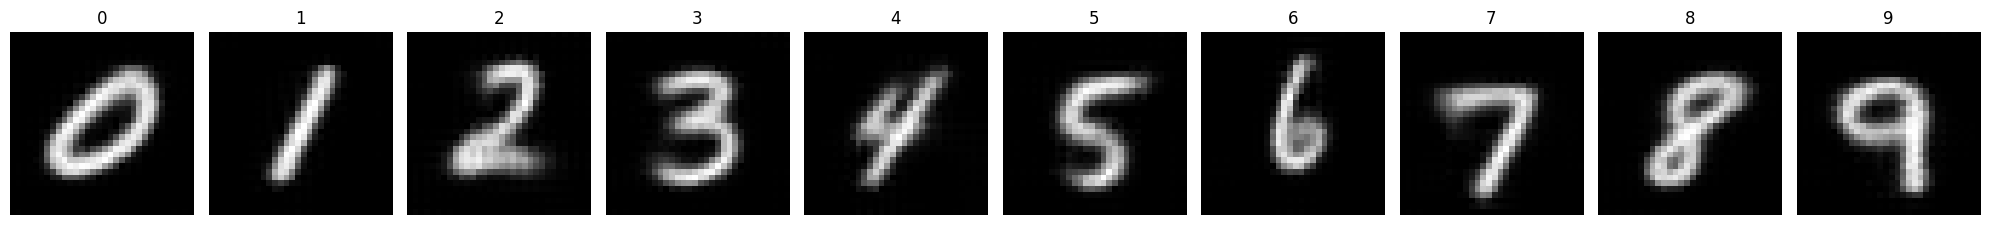

Epoch 19/50
468/468 [==============================] - 43s 93ms/step - loss: 0.1319 - noise_loss: 0.1013 - kl_loss: 3.0629 - val_loss: 0.1301 - val_noise_loss: 0.1003 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.9748 - learning_rate: 6.8406e-04


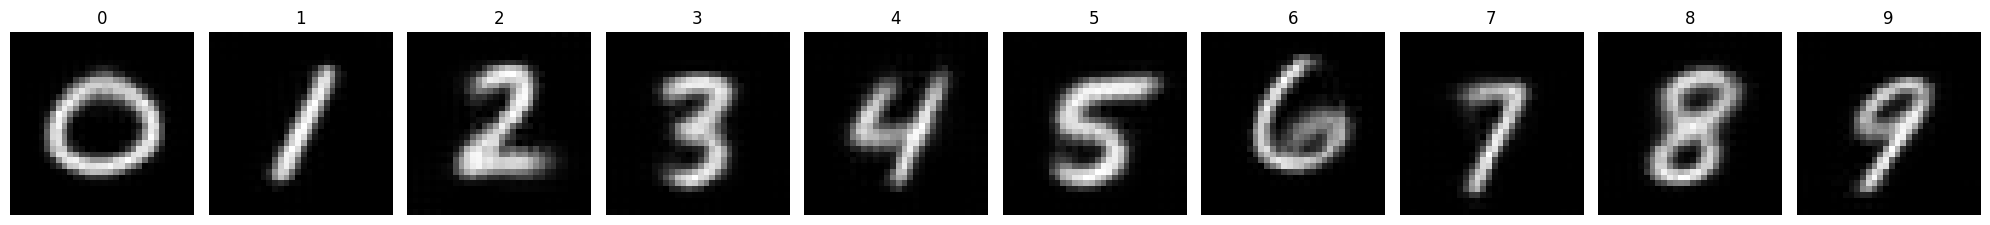

Epoch 20/50
468/468 [==============================] - 43s 92ms/step - loss: 0.1315 - noise_loss: 0.1005 - kl_loss: 3.1007 - val_loss: 0.1295 - val_noise_loss: 0.0994 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.0093 - learning_rate: 6.5451e-04


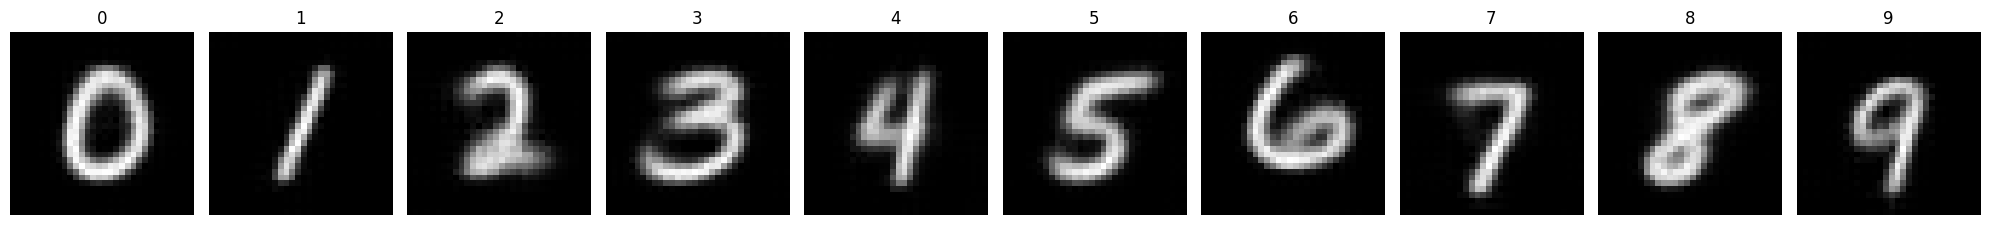

Epoch 21/50
468/468 [==============================] - 43s 93ms/step - loss: 0.1312 - noise_loss: 0.1000 - kl_loss: 3.1214 - val_loss: 0.1292 - val_noise_loss: 0.0988 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.0408 - learning_rate: 6.2435e-04


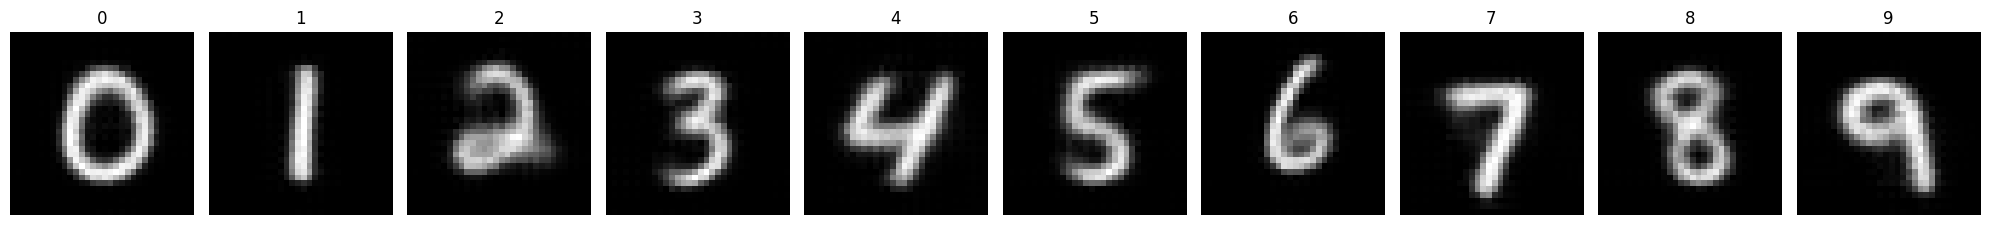

Epoch 22/50
468/468 [==============================] - 43s 93ms/step - loss: 0.1311 - noise_loss: 0.0997 - kl_loss: 3.1450 - val_loss: 0.1292 - val_noise_loss: 0.0985 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.0703 - learning_rate: 5.9369e-04


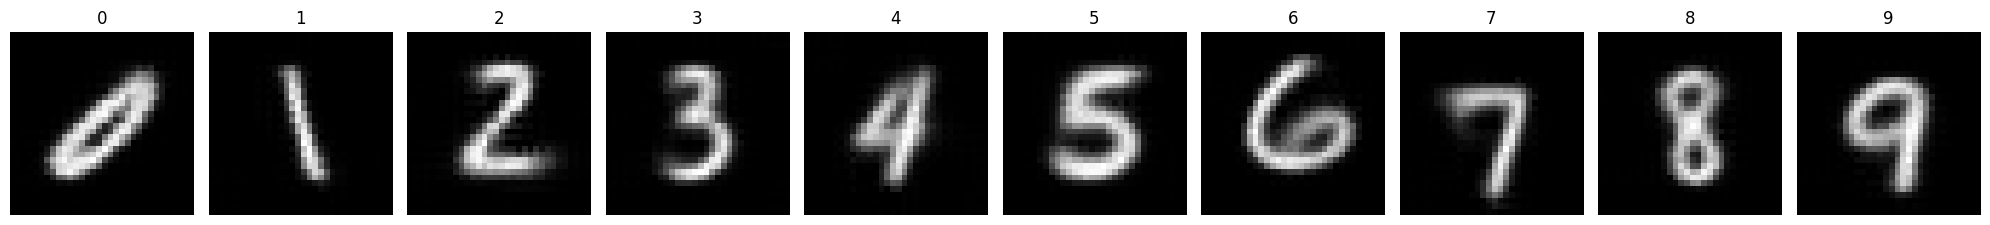

Epoch 23/50
468/468 [==============================] - 44s 94ms/step - loss: 0.1307 - noise_loss: 0.0990 - kl_loss: 3.1710 - val_loss: 0.1291 - val_noise_loss: 0.0982 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.0975 - learning_rate: 5.6267e-04


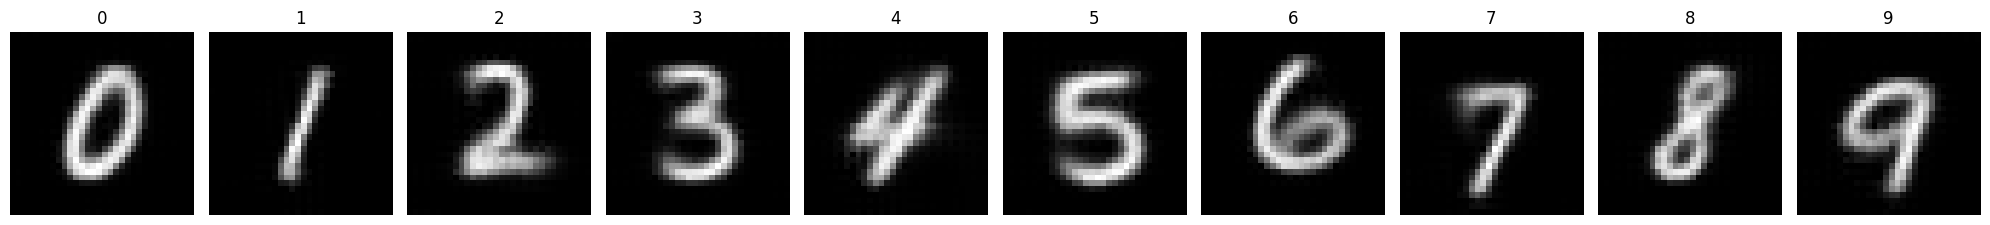

Epoch 24/50
468/468 [==============================] - 43s 93ms/step - loss: 0.1305 - noise_loss: 0.0984 - kl_loss: 3.2027 - val_loss: 0.1289 - val_noise_loss: 0.0976 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.1292 - learning_rate: 5.3140e-04


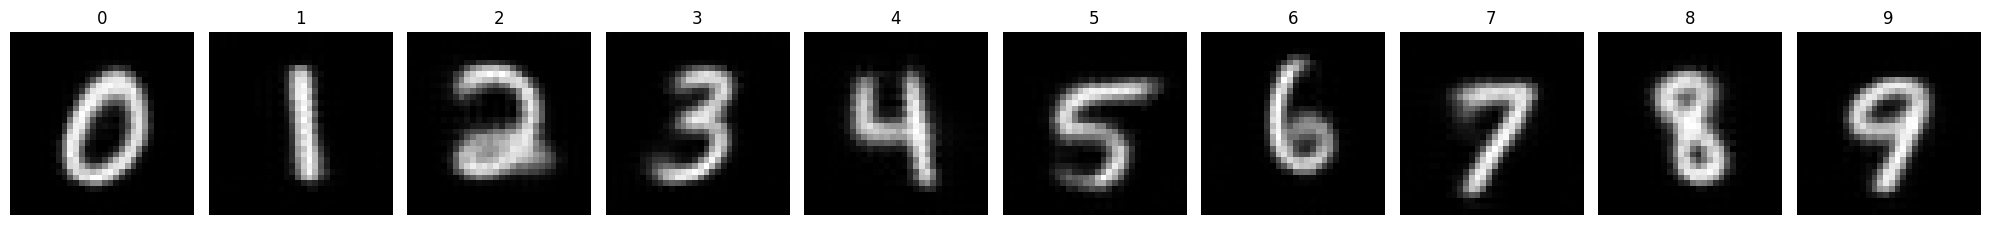

Epoch 25/50
468/468 [==============================] - 43s 92ms/step - loss: 0.1302 - noise_loss: 0.0980 - kl_loss: 3.2207 - val_loss: 0.1285 - val_noise_loss: 0.0969 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.1569 - learning_rate: 5.0000e-04


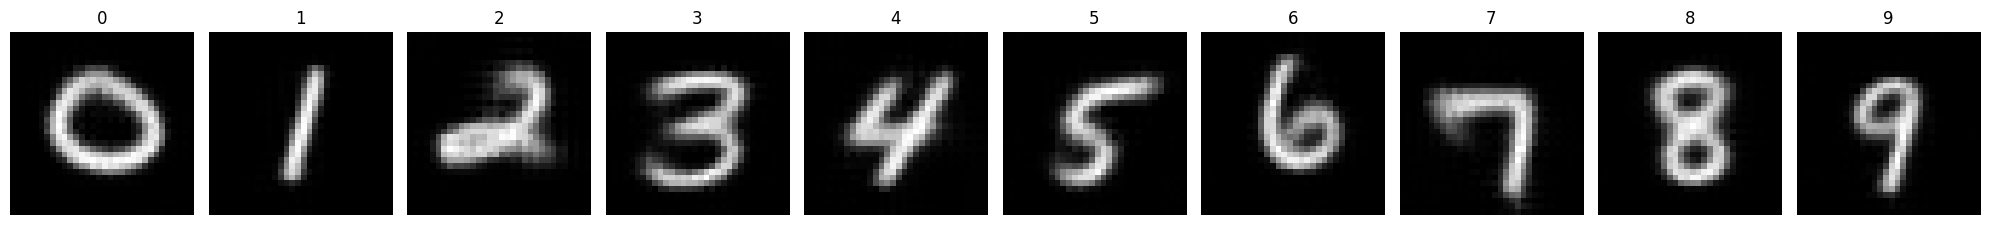

Epoch 26/50
468/468 [==============================] - 44s 93ms/step - loss: 0.1299 - noise_loss: 0.0975 - kl_loss: 3.2375 - val_loss: 0.1282 - val_noise_loss: 0.0964 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.1803 - learning_rate: 4.6860e-04


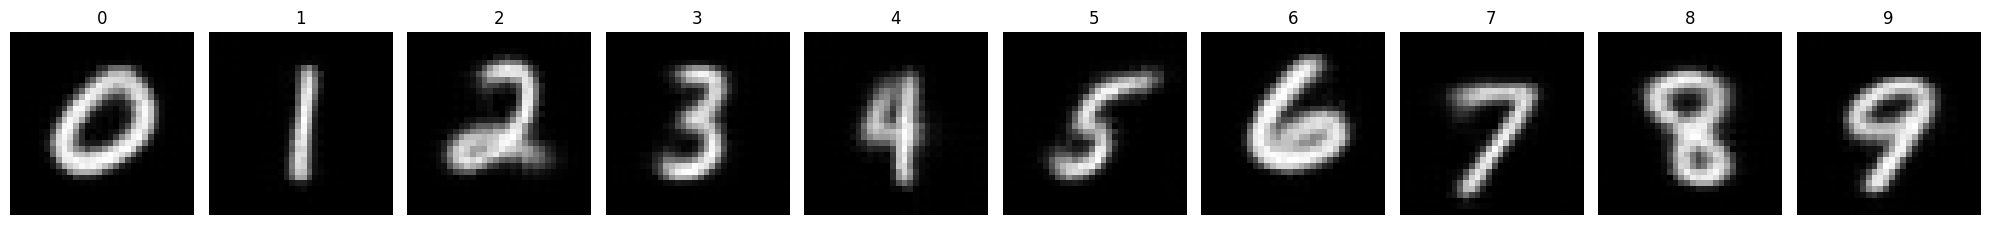

Epoch 27/50
468/468 [==============================] - 43s 93ms/step - loss: 0.1298 - noise_loss: 0.0972 - kl_loss: 3.2609 - val_loss: 0.1280 - val_noise_loss: 0.0959 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.2043 - learning_rate: 4.3733e-04


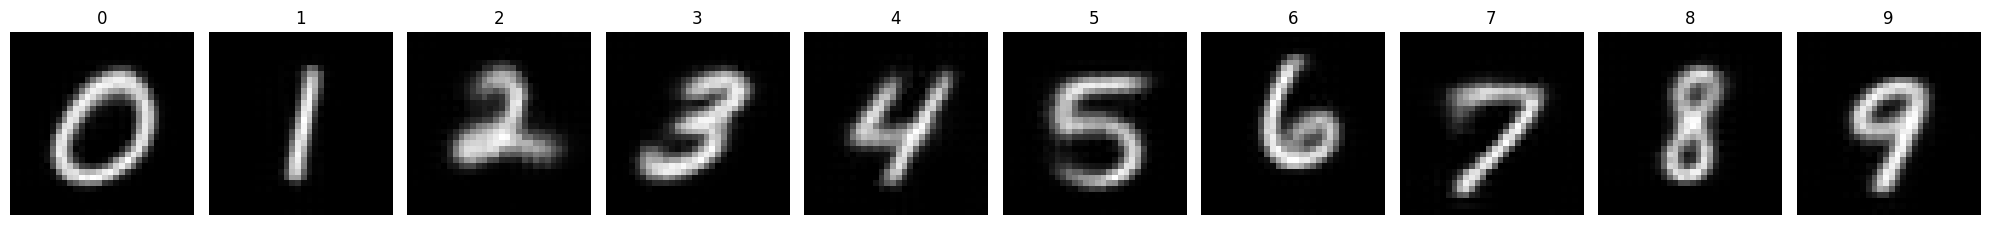

Epoch 28/50
468/468 [==============================] - 44s 93ms/step - loss: 0.1295 - noise_loss: 0.0968 - kl_loss: 3.2704 - val_loss: 0.1281 - val_noise_loss: 0.0959 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.2231 - learning_rate: 4.0631e-04


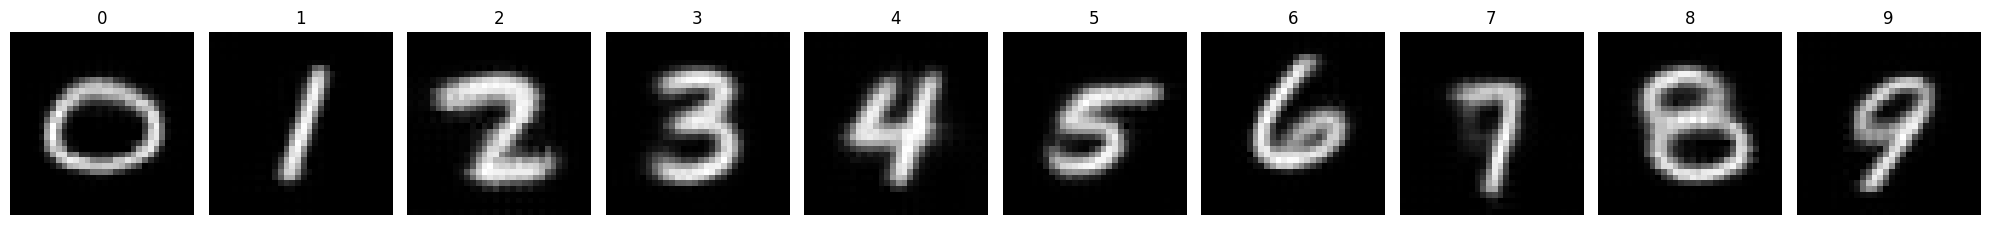

Epoch 29/50
468/468 [==============================] - 43s 92ms/step - loss: 0.1293 - noise_loss: 0.0964 - kl_loss: 3.2890 - val_loss: 0.1280 - val_noise_loss: 0.0956 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.2428 - learning_rate: 3.7566e-04


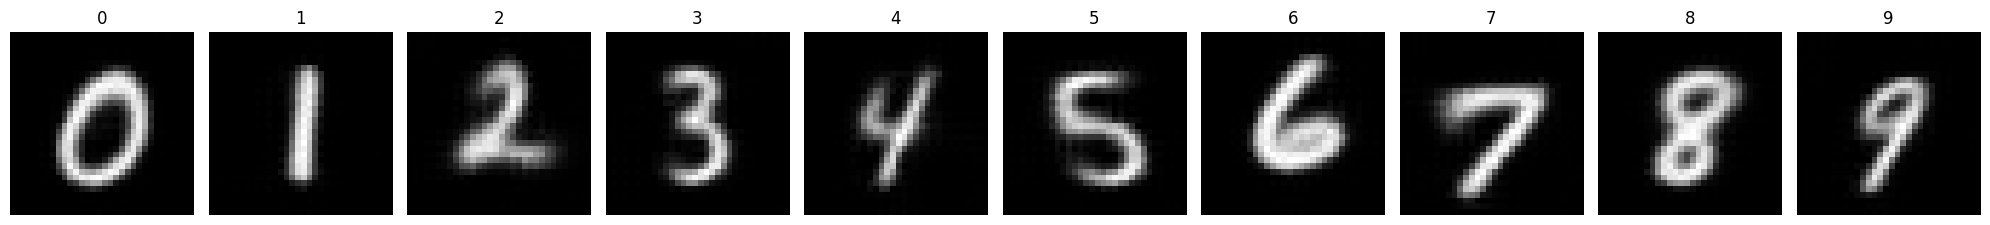

Epoch 30/50
468/468 [==============================] - 43s 92ms/step - loss: 0.1293 - noise_loss: 0.0962 - kl_loss: 3.3100 - val_loss: 0.1277 - val_noise_loss: 0.0951 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.2620 - learning_rate: 3.4549e-04


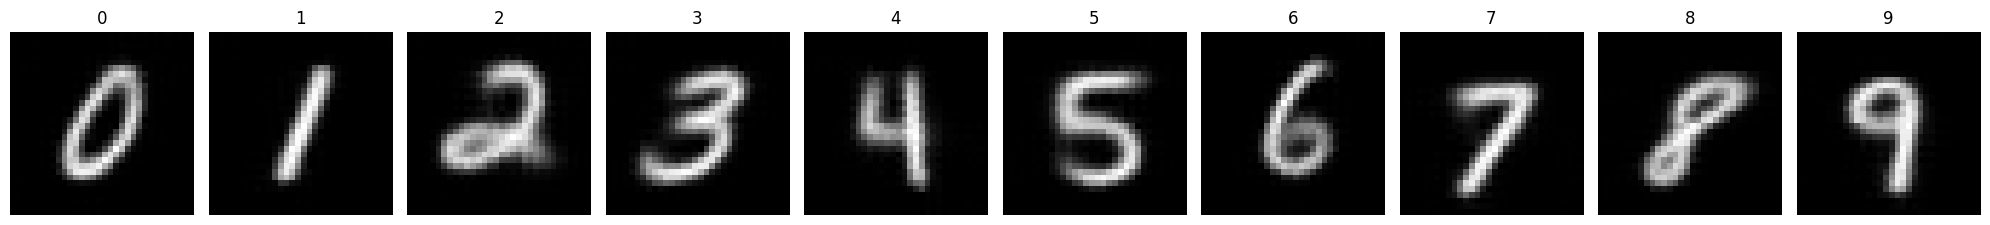

Epoch 31/50
468/468 [==============================] - 43s 92ms/step - loss: 0.1291 - noise_loss: 0.0958 - kl_loss: 3.3294 - val_loss: 0.1278 - val_noise_loss: 0.0950 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.2825 - learning_rate: 3.1594e-04


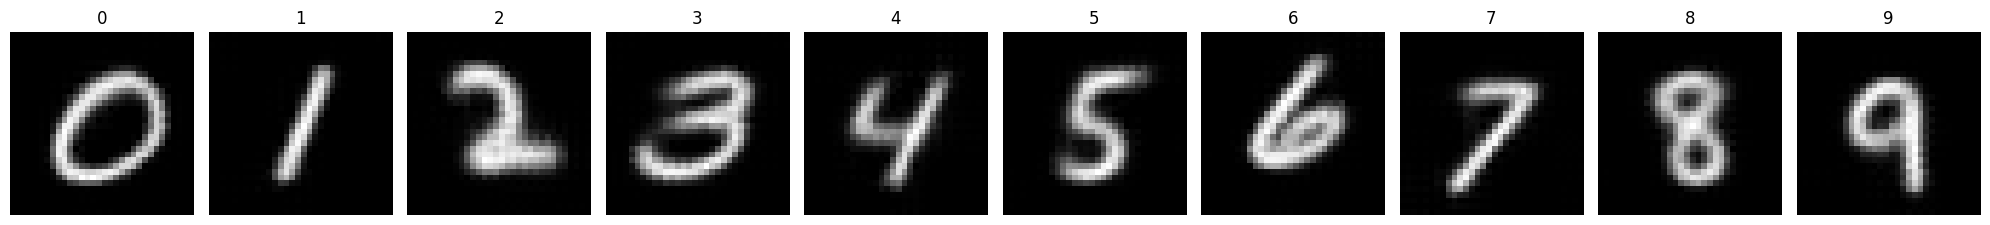

Epoch 32/50
468/468 [==============================] - 43s 92ms/step - loss: 0.1289 - noise_loss: 0.0955 - kl_loss: 3.3373 - val_loss: 0.1275 - val_noise_loss: 0.0945 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.2994 - learning_rate: 2.8711e-04


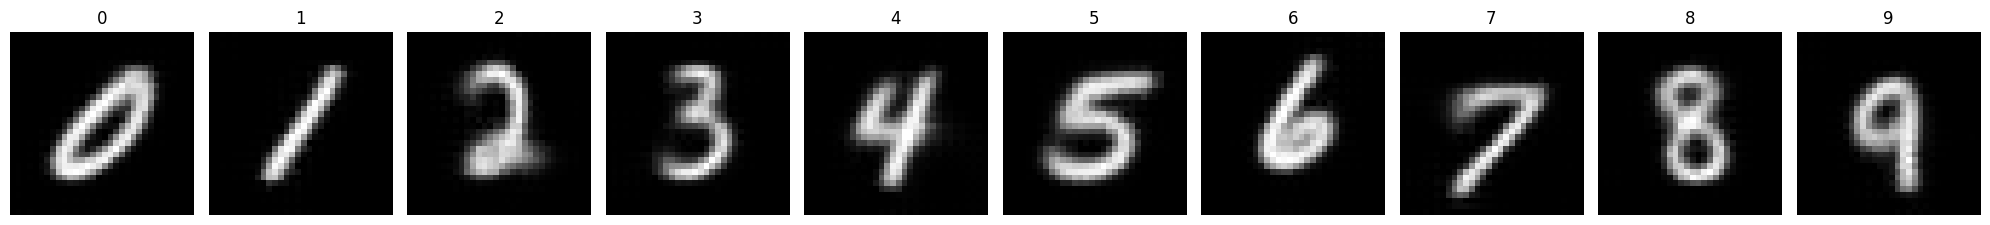

Epoch 33/50
468/468 [==============================] - 43s 93ms/step - loss: 0.1286 - noise_loss: 0.0952 - kl_loss: 3.3418 - val_loss: 0.1273 - val_noise_loss: 0.0942 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.3109 - learning_rate: 2.5912e-04


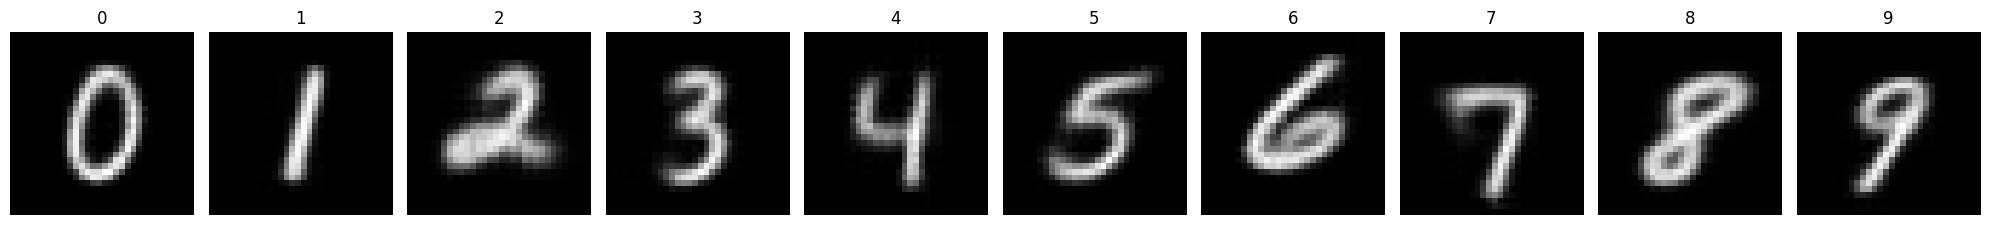

Epoch 34/50
468/468 [==============================] - 43s 92ms/step - loss: 0.1285 - noise_loss: 0.0949 - kl_loss: 3.3636 - val_loss: 0.1274 - val_noise_loss: 0.0941 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.3272 - learning_rate: 2.3209e-04


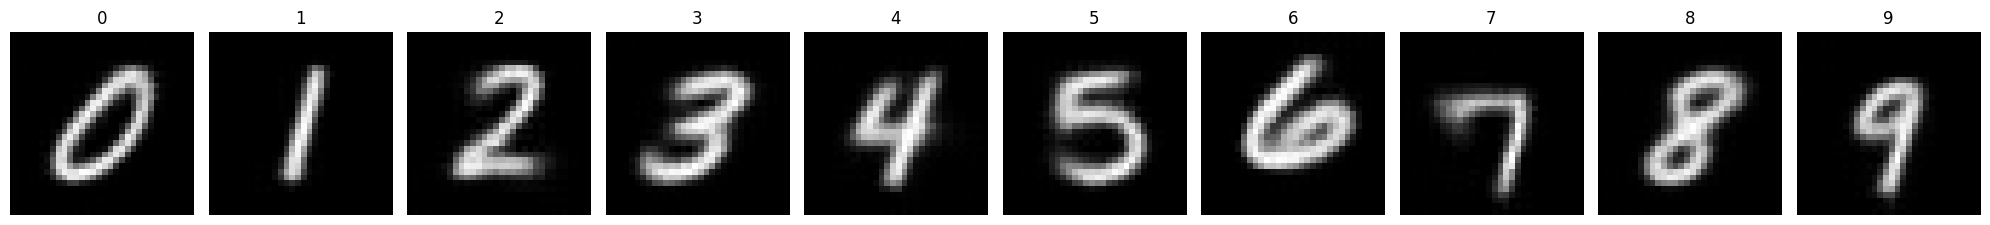

Epoch 35/50
468/468 [==============================] - 42s 90ms/step - loss: 0.1284 - noise_loss: 0.0947 - kl_loss: 3.3695 - val_loss: 0.1270 - val_noise_loss: 0.0936 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.3404 - learning_rate: 2.0611e-04


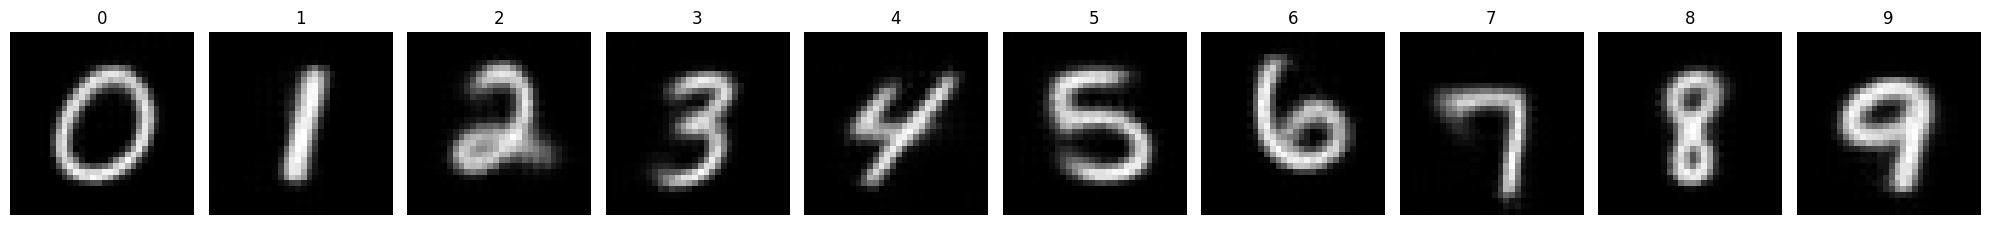

Epoch 36/50
468/468 [==============================] - 43s 91ms/step - loss: 0.1283 - noise_loss: 0.0945 - kl_loss: 3.3784 - val_loss: 0.1274 - val_noise_loss: 0.0939 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.3511 - learning_rate: 1.8129e-04


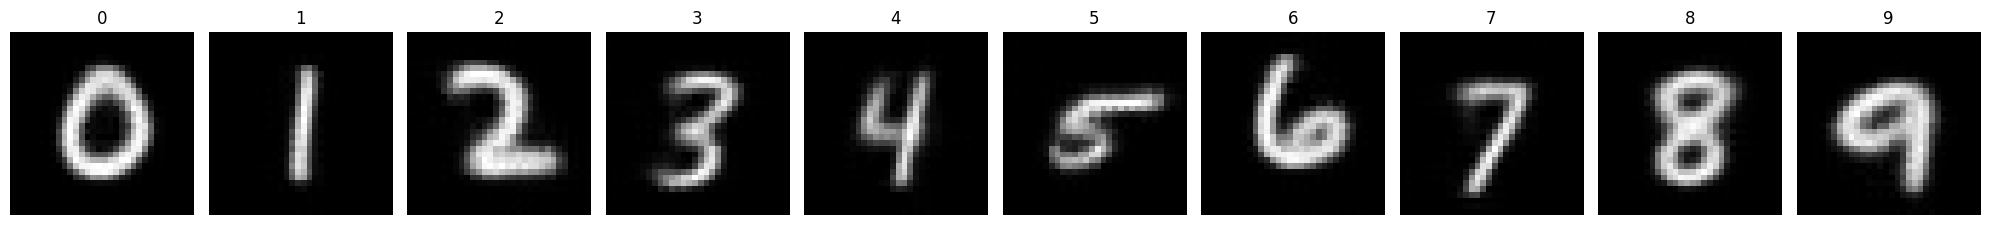

Epoch 37/50
468/468 [==============================] - 43s 92ms/step - loss: 0.1282 - noise_loss: 0.0943 - kl_loss: 3.3939 - val_loss: 0.1272 - val_noise_loss: 0.0936 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.3641 - learning_rate: 1.5773e-04


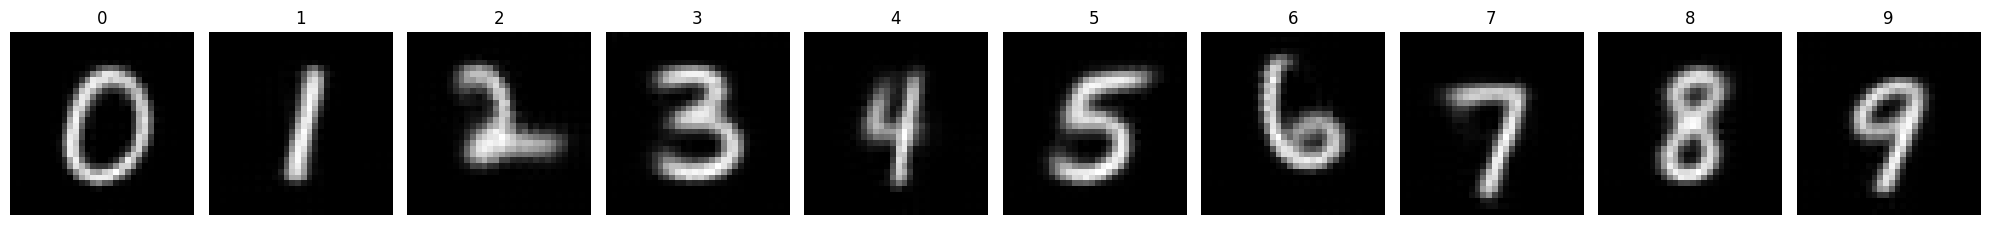

Epoch 38/50
468/468 [==============================] - 43s 91ms/step - loss: 0.1281 - noise_loss: 0.0942 - kl_loss: 3.3849 - val_loss: 0.1273 - val_noise_loss: 0.0936 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.3697 - learning_rate: 1.3552e-04


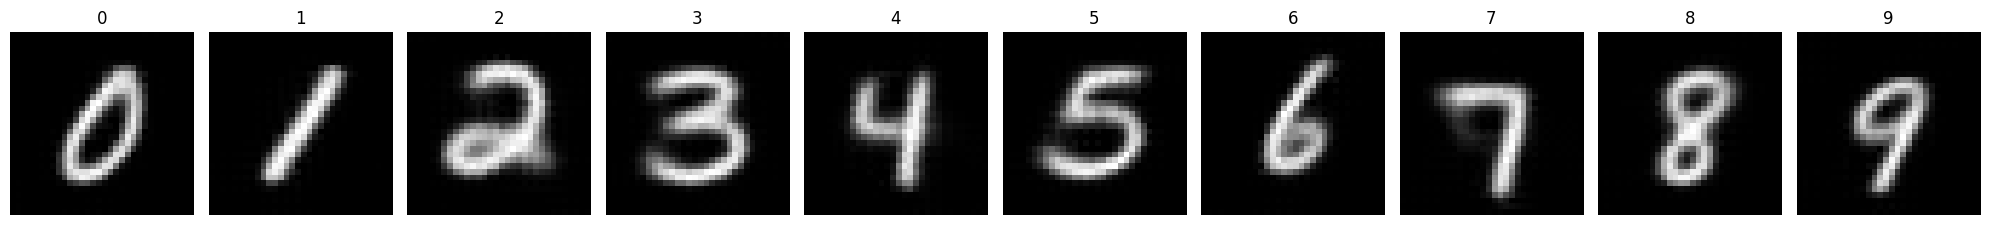

Epoch 39/50
468/468 [==============================] - 42s 91ms/step - loss: 0.1280 - noise_loss: 0.0940 - kl_loss: 3.3971 - val_loss: 0.1270 - val_noise_loss: 0.0932 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.3773 - learning_rate: 1.1474e-04


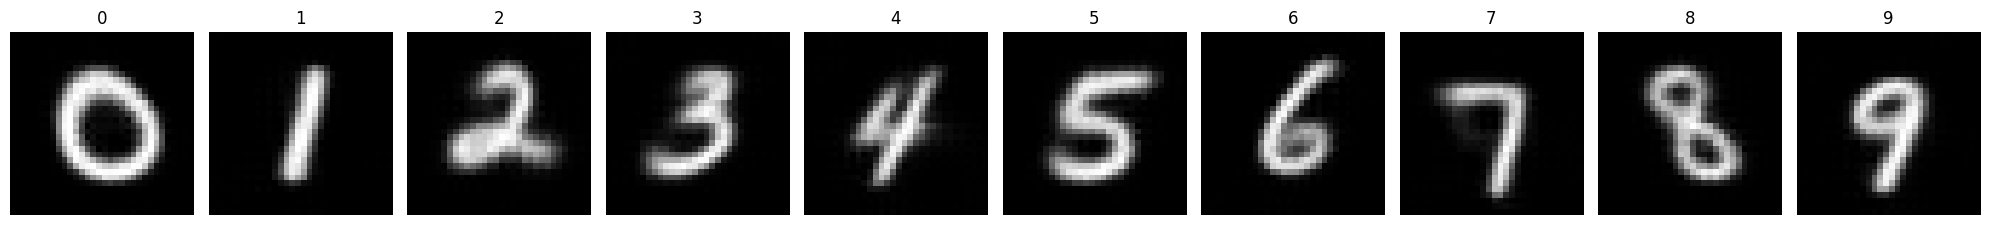

Epoch 40/50
468/468 [==============================] - 43s 92ms/step - loss: 0.1279 - noise_loss: 0.0938 - kl_loss: 3.4110 - val_loss: 0.1270 - val_noise_loss: 0.0932 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.3866 - learning_rate: 9.5491e-05


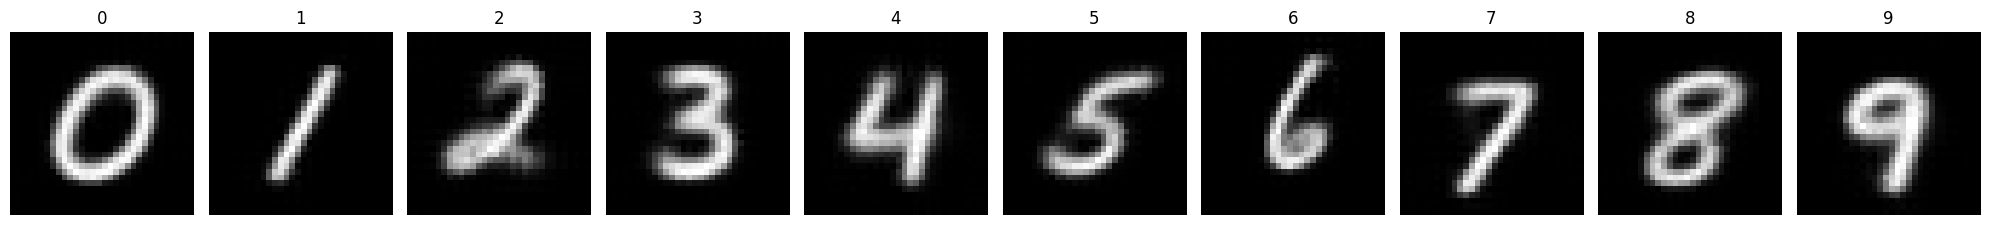

Epoch 41/50
468/468 [==============================] - 43s 91ms/step - loss: 0.1279 - noise_loss: 0.0937 - kl_loss: 3.4197 - val_loss: 0.1270 - val_noise_loss: 0.0930 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.3970 - learning_rate: 7.7836e-05


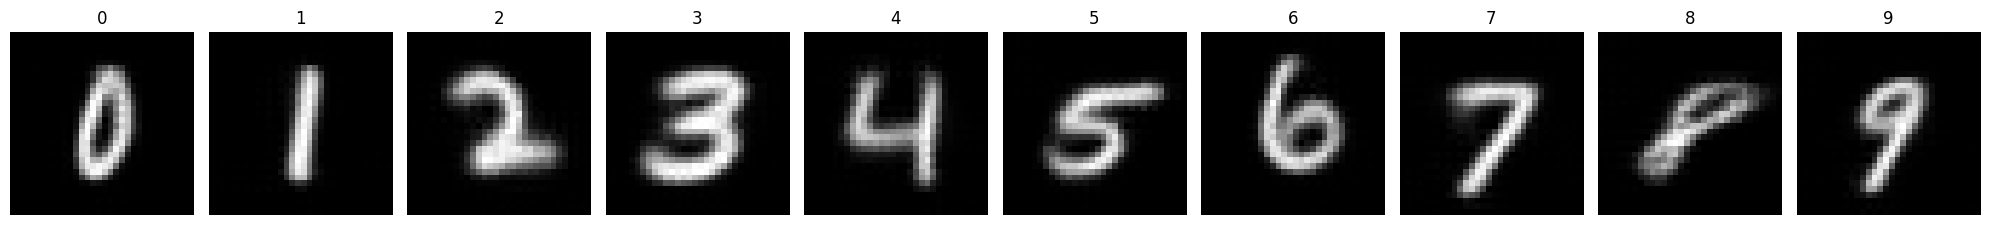

Epoch 42/50
468/468 [==============================] - 43s 92ms/step - loss: 0.1277 - noise_loss: 0.0936 - kl_loss: 3.4163 - val_loss: 0.1270 - val_noise_loss: 0.0930 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.4018 - learning_rate: 6.1847e-05


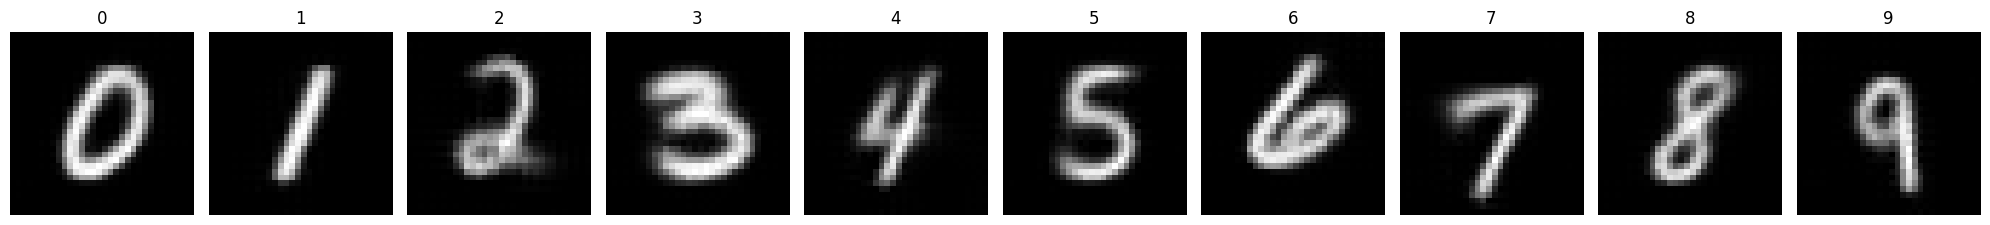

Epoch 43/50
468/468 [==============================] - 41s 87ms/step - loss: 0.1277 - noise_loss: 0.0935 - kl_loss: 3.4158 - val_loss: 0.1270 - val_noise_loss: 0.0930 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.4047 - learning_rate: 4.7586e-05


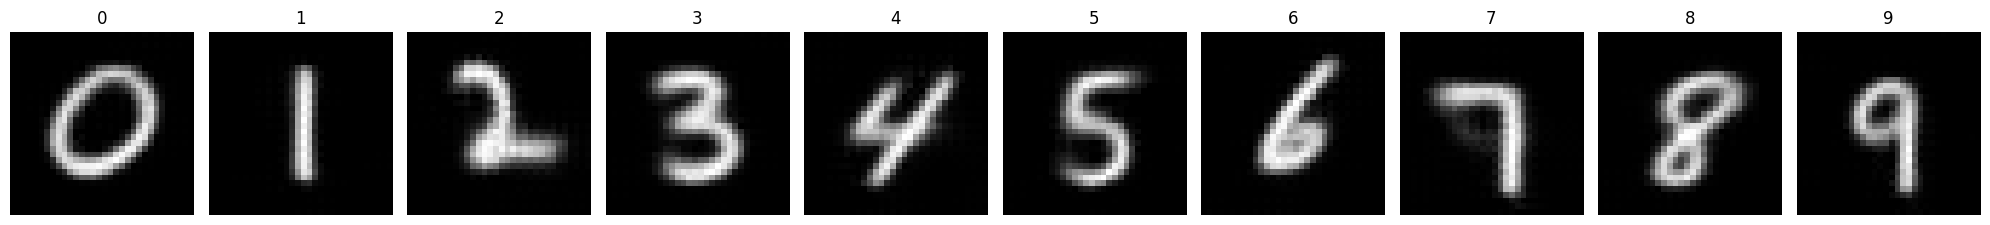

Epoch 44/50
468/468 [==============================] - 41s 87ms/step - loss: 0.1274 - noise_loss: 0.0932 - kl_loss: 3.4200 - val_loss: 0.1268 - val_noise_loss: 0.0927 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.4076 - learning_rate: 3.5112e-05


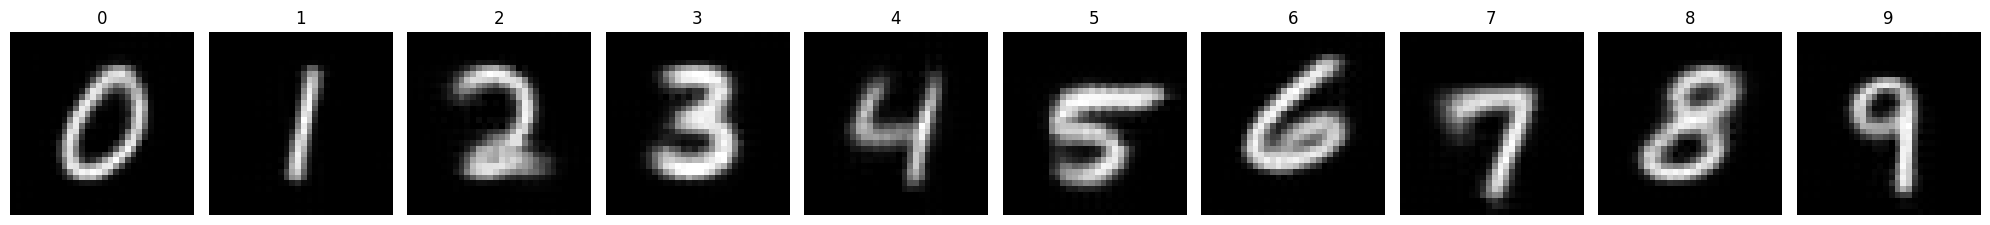

Epoch 45/50
468/468 [==============================] - 41s 88ms/step - loss: 0.1275 - noise_loss: 0.0933 - kl_loss: 3.4193 - val_loss: 0.1273 - val_noise_loss: 0.0932 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.4098 - learning_rate: 2.4472e-05


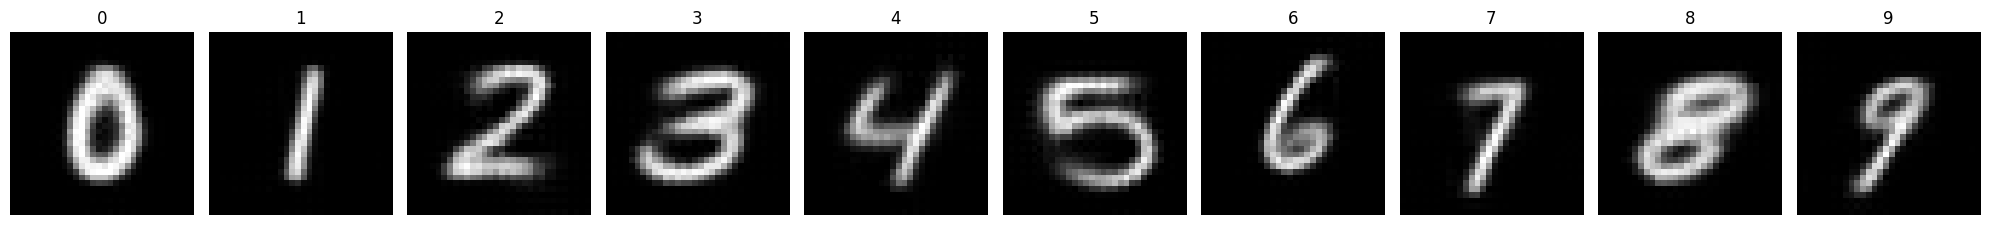

Epoch 46/50
468/468 [==============================] - 41s 88ms/step - loss: 0.1274 - noise_loss: 0.0931 - kl_loss: 3.4310 - val_loss: 0.1271 - val_noise_loss: 0.0929 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.4154 - learning_rate: 1.5708e-05


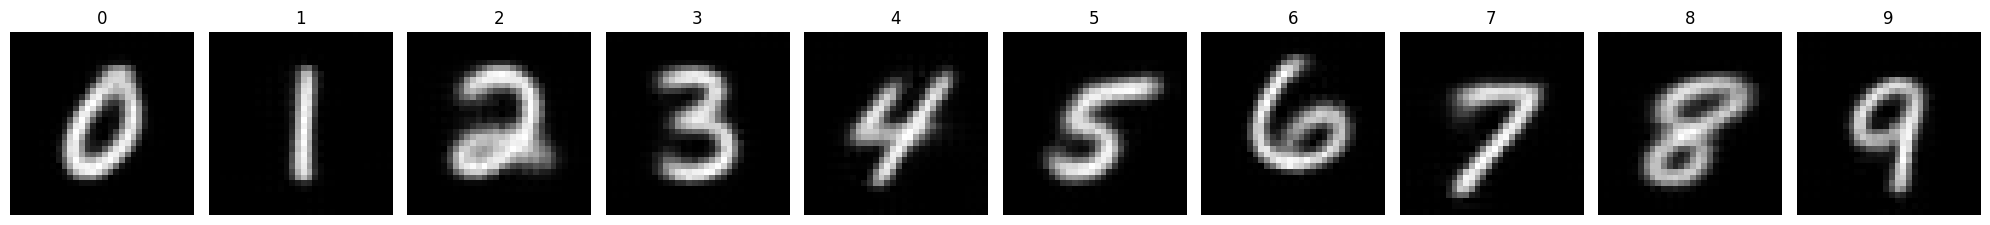

Epoch 47/50
468/468 [==============================] - 41s 87ms/step - loss: 0.1275 - noise_loss: 0.0931 - kl_loss: 3.4348 - val_loss: 0.1267 - val_noise_loss: 0.0925 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.4207 - learning_rate: 8.8564e-06


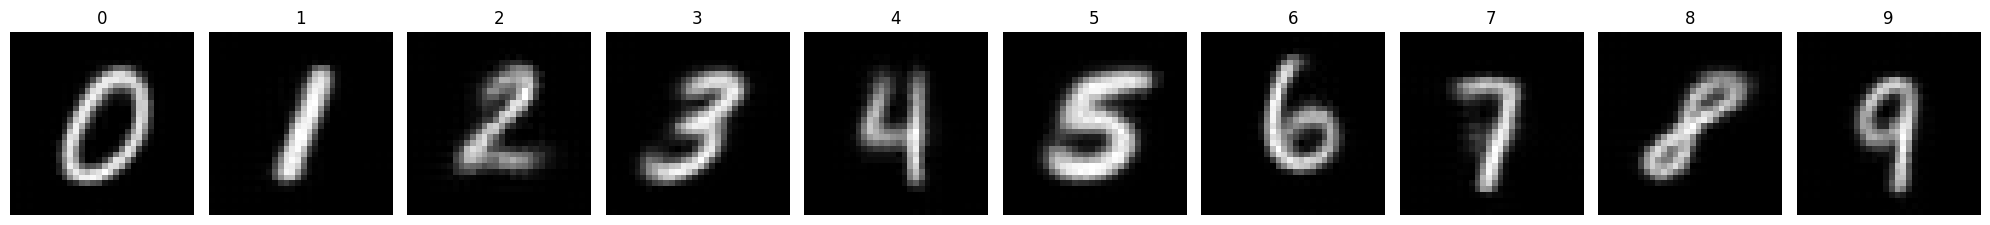

Epoch 48/50
468/468 [==============================] - 41s 88ms/step - loss: 0.1273 - noise_loss: 0.0930 - kl_loss: 3.4364 - val_loss: 0.1270 - val_noise_loss: 0.0927 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.4242 - learning_rate: 3.9426e-06


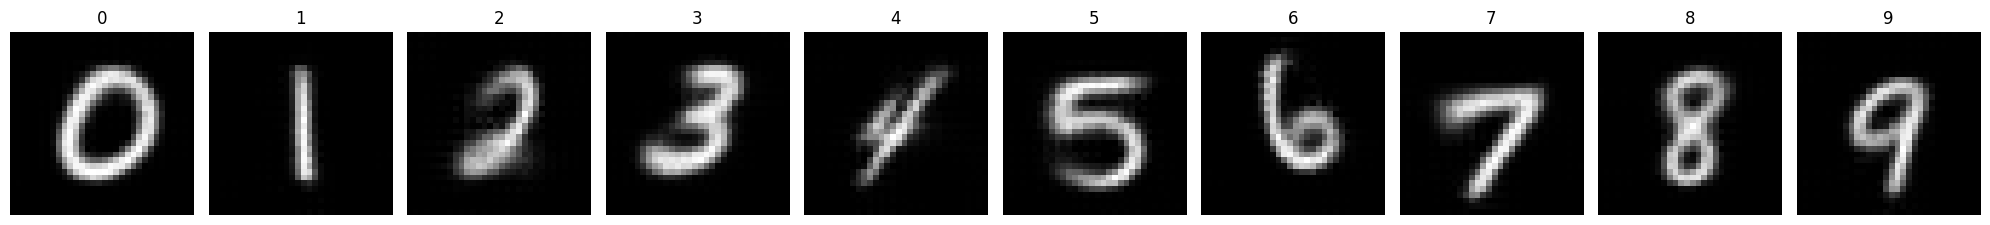

Epoch 49/50
468/468 [==============================] - 41s 87ms/step - loss: 0.1273 - noise_loss: 0.0930 - kl_loss: 3.4340 - val_loss: 0.1268 - val_noise_loss: 0.0925 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.4255 - learning_rate: 9.8664e-07


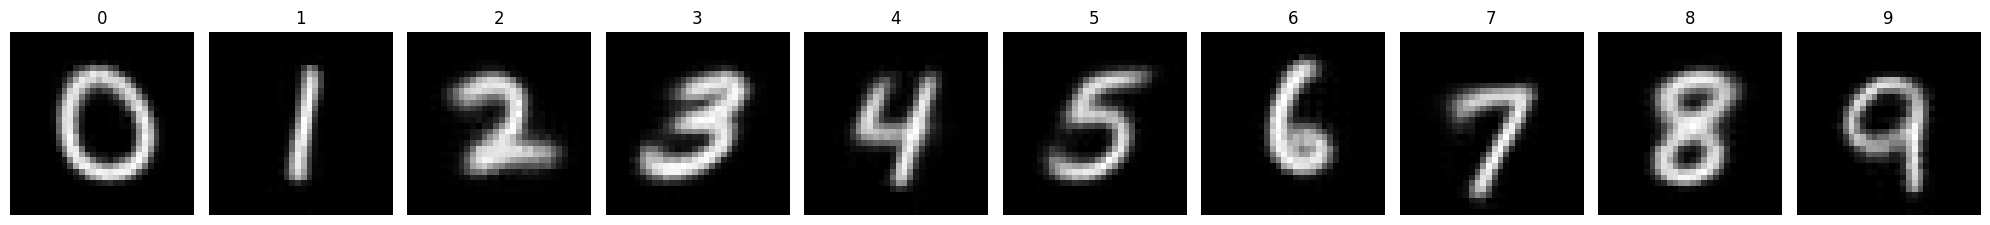

Epoch 50/50
468/468 [==============================] - 41s 87ms/step - loss: 0.1273 - noise_loss: 0.0930 - kl_loss: 3.4324 - val_loss: 0.1269 - val_noise_loss: 0.0926 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.4259 - learning_rate: 0.0000e+00


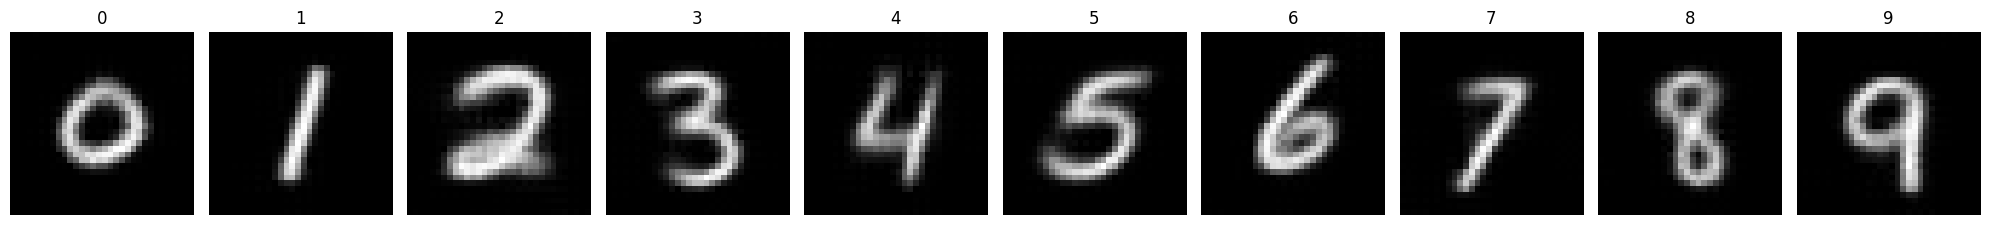

In [12]:
history = model.fit(
    trainset, 
    epochs=epochs, 
    validation_data=valset, 
    callbacks=callbacks_list, 
).history

In [13]:
# history = model.fit_progressively(
#     x=trainset.take(1), 
#     num_stages=10, 
#     stage_epochs=epochs, 
#     pacing_type="plateau", 
#     monitor="val_noise_loss", 
#     min_delta=1e-3, 
#     patience=1, 
#     validation_data=valset, 
#     callbacks=callbacks_list, 
# ).history

In [14]:
model.evaluate(valset)

79/79 [==============================] - 6s 45ms/step - loss: 0.1265 - noise_loss: 0.0922 - image_loss: 0.0000e+00 - kl_loss: 3.4259


[0.12646684050559998, 0.09220760315656662, 0.0, 3.42592191696167]

In [15]:
model.evaluate(valset, network_name="raw")

79/79 [==============================] - 5s 44ms/step - loss: 0.1270 - noise_loss: 0.0927 - image_loss: 0.0000e+00 - kl_loss: 3.4263


[0.12695489823818207, 0.09269191324710846, 0.0, 3.4262969493865967]

In [16]:
from common.utils import plot_images


# imgs = model.sample(labels=list(range(11)), scale=3., steps=1_000, eta=1., verbose=True)
# plot_images(imgs)

In [17]:
# model.set_current_resolution(32)

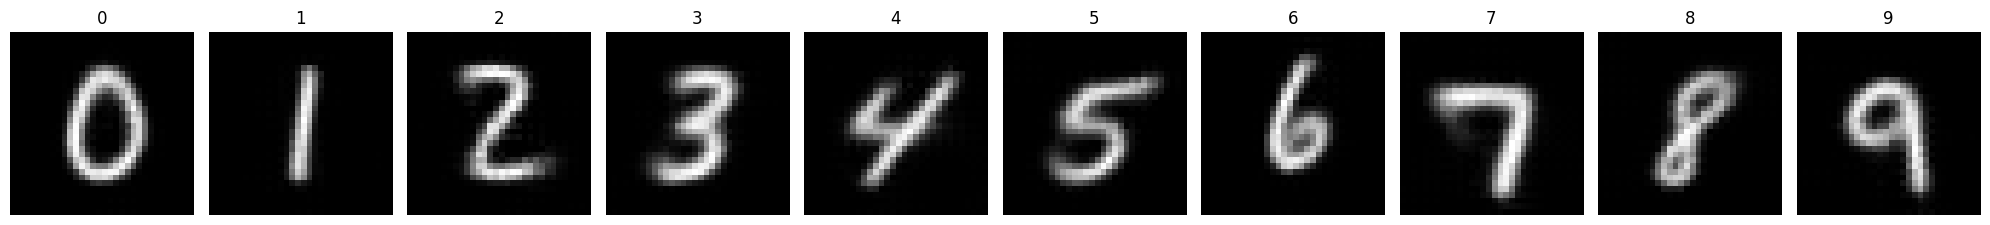

In [18]:
imgs = model.sample(labels=list(range(10)), verbose=True)
plot_images(imgs)

In [19]:
# imgs = model.sample(labels=list(range(11)), verbose=True)
# plot_images(imgs)

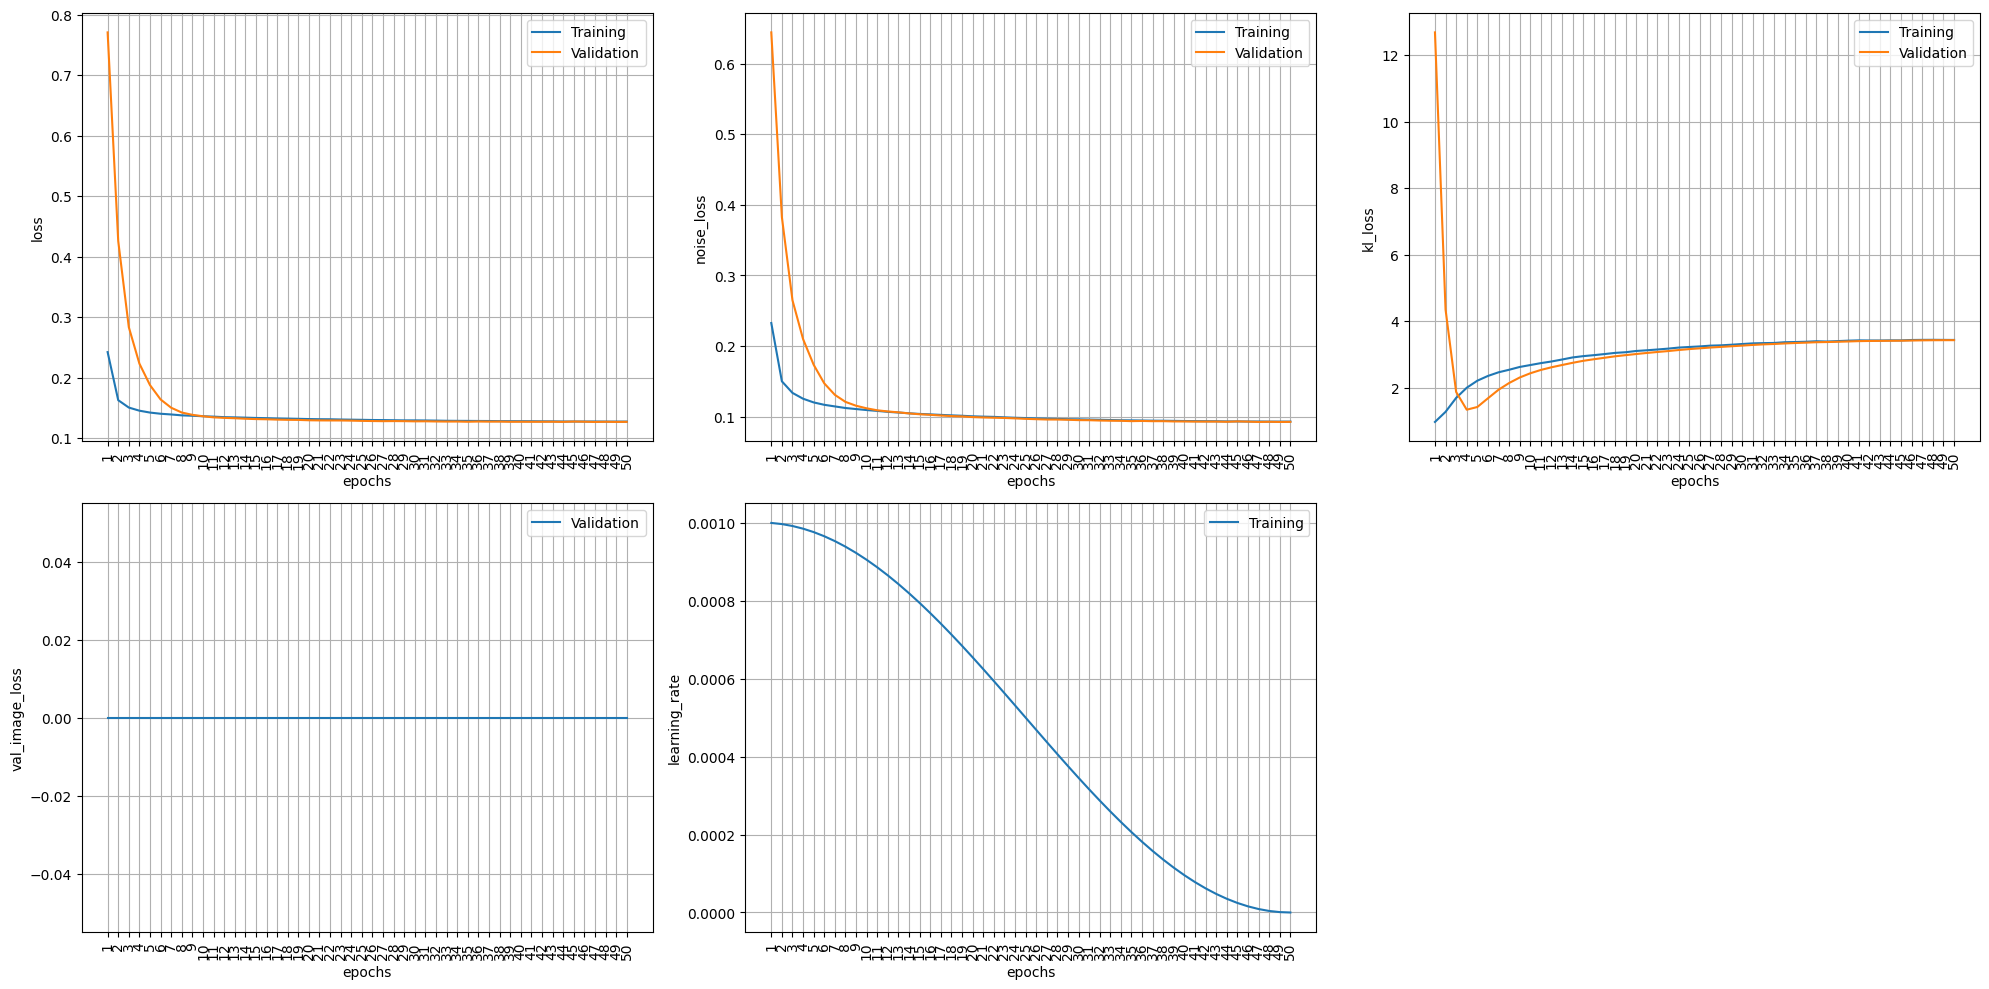

In [20]:
from common.utils import plot_history


plot_history(history)

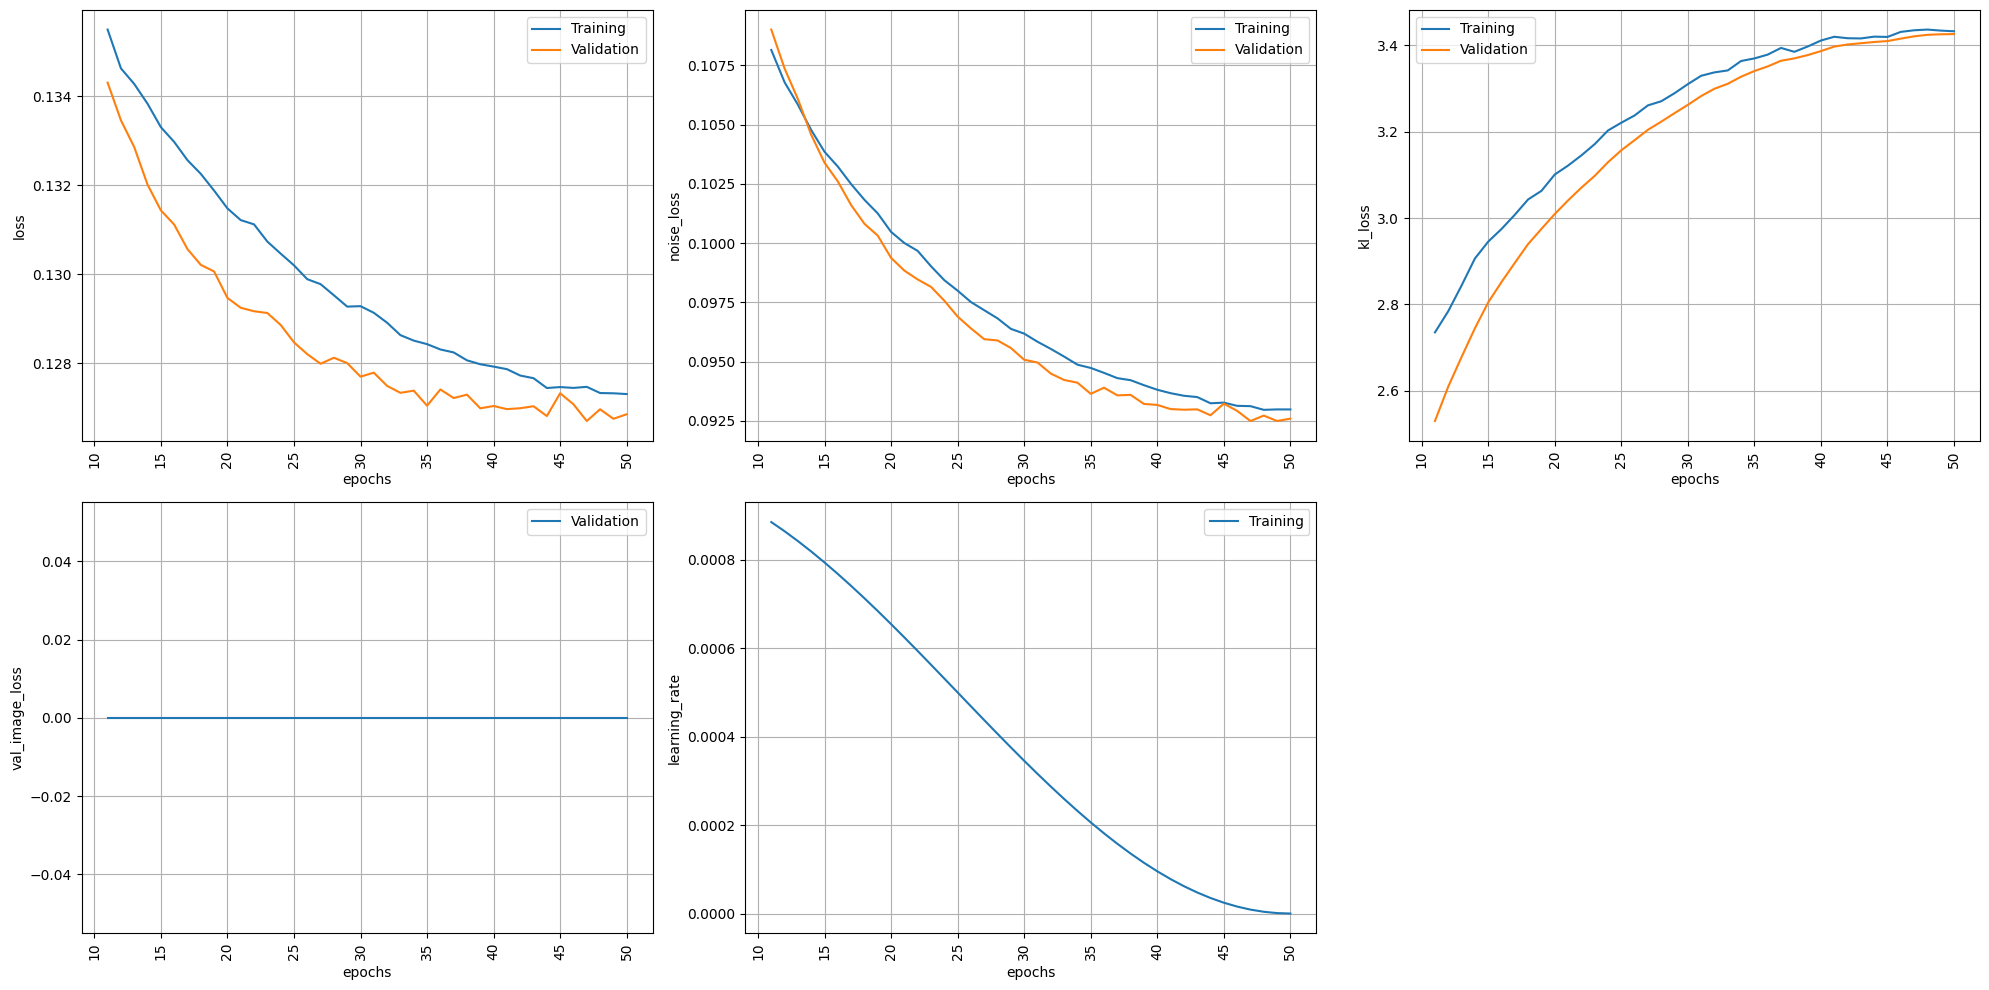

In [21]:
plot_history(history, show_all_x_ticks=False, range_=(10, None))